# derived_8.4-regime-interpretation-1.2-ece — In-Situ ECE Sensor Regime Distribution & Environmental Interpretation

This experiment evaluates the **generalization of the 5 two-regime routing strategies** of `derived_8.4-eval-1.1` — `Clustering_V0_Full_k2` (the winning 50-feature router), `Clustering_Dynamic_k2`, `Seasonal_Binary_k2`, `Univariate_G_API_k2`, and `Trained_Gating_k2` — on the **5 in-situ ECE soil moisture sensor stations** in Washington State (`derived_8.4-ece`).

The routers are fitted **strictly on the 7 Washington reference stations** from `derived_8.4` (`trainval`, 2017–2022, 14,608 rows). The in-situ ECE dataset `derived_8.4-ece` (150 rows across 5 micro-stations at Bellevue Botanical Garden and Renton, July–August 2026) is treated as a **completely held-out test set** to inspect regime assignment, station purity, dynamic weather drivers, static environmental attributes, and micro-scale vs macro-scale clustering behavior in Western Washington.


In [1]:
"""Setup: reproduce the eval-1.1 routers for all five k2 strategies on derived_8.4, and evaluate on derived_8.4-ece."""
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

PROJECT_ROOT = Path("../../..").resolve()
SPLIT_DIR_WA = PROJECT_ROOT / "data" / "splits" / "derived_8.4"
SPLIT_DIR_ECE = PROJECT_ROOT / "data" / "splits" / "derived_8.4-ece"
EVAL_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.4-eval-1.1"
EXP_DIR = Path(".").resolve()


# --- Load splits (same preparation as eval-1.1 eval11/data.py) ---
def load_frame(path: Path) -> pd.DataFrame:
    base = pd.read_csv(path)
    dates = pd.to_datetime(base["date"], errors="raise")
    derived = pd.DataFrame(
        {"date": dates, "month": dates.dt.month.astype(int), "year": dates.dt.year.astype(int)}
    )
    return pd.concat([base.drop(columns=["date", "month", "year"], errors="ignore"), derived], axis=1)


train_wa = load_frame(SPLIT_DIR_WA / "train.csv")
val_wa = load_frame(SPLIT_DIR_WA / "val.csv")
test_wa = load_frame(SPLIT_DIR_WA / "test.csv")
trainval_wa = pd.concat([train_wa, val_wa], axis=0, ignore_index=True)

# In-situ ECE held-out dataset
ece_test = load_frame(SPLIT_DIR_ECE / "test.csv")

# Aliases for consistent downstream evaluation
trainval = trainval_wa
test = ece_test
test_wa_ref = test_wa

# --- Load the 50 V0 features from dataset metadata ---
spec = importlib.util.spec_from_file_location("dataset_metadata", SPLIT_DIR_WA / "dataset_metadata.py")
metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metadata)
V0_FEATURES = list(metadata.OVERALL_SELECTED_FEATURES_V0)
TARGET = "soil_moisture_5cm"

# --- Import the exact router classes used by eval-1.1 ---
sys.path.insert(0, str(EVAL_DIR))
from eval11.routers import (  # noqa: E402
    DynamicClusterRouter,
    SeasonalBinaryRouter,
    TrainedGatingRouter,
    UnivariateGAPIRouter,
    V0FullRouter,
)

ROUTER_FACTORIES = {
    "Clustering_V0_Full_k2": lambda: V0FullRouter(V0_FEATURES, seed=42),
    "Clustering_Dynamic_k2": lambda: DynamicClusterRouter(seed=42),
    "Seasonal_Binary_k2": lambda: SeasonalBinaryRouter(),
    "Univariate_G_API_k2": lambda: UnivariateGAPIRouter(),
    "Trained_Gating_k2": lambda: TrainedGatingRouter(V0_FEATURES, seed=42, device="cpu"),
}

labels = {}
for strategy, factory in ROUTER_FACTORIES.items():
    router = factory()
    router.fit(trainval_wa)
    labels[(strategy, "trainval")] = router.predict(trainval_wa)
    labels[(strategy, "test_wa")] = router.predict(test_wa)
    labels[(strategy, "test")] = router.predict(ece_test)

print(f"WA trainval (fitted on): {len(trainval_wa)} rows (7 stations)")
print(f"WA test (in-sample check): {len(test_wa)} rows")
print(f"ECE held-out dataset: {len(ece_test)} rows (5 stations across Jul-Aug 2026)")
print(f"V0 features: {len(V0_FEATURES)}")
for strategy in ROUTER_FACTORIES:
    lt = labels[(strategy, "trainval")]
    lo = labels[(strategy, "test")]
    print(
        f"{strategy:24s} WA trainval 0 -> {int((lt == 0).sum())} ({float((lt == 0).mean()):.1%}), 1 -> {int((lt == 1).sum())} ({float((lt == 1).mean()):.1%})"
        f"  |  ECE 0 -> {int((lo == 0).sum())} ({float((lo == 0).mean()):.1%}), 1 -> {int((lo == 1).sum())} ({float((lo == 1).mean()):.1%})"
    )


WA trainval (fitted on): 14608 rows (7 stations)
WA test (in-sample check): 6620 rows
ECE held-out dataset: 150 rows (5 stations across Jul-Aug 2026)
V0 features: 50
Clustering_V0_Full_k2    WA trainval 0 -> 10624 (72.7%), 1 -> 3984 (27.3%)  |  ECE 0 -> 89 (59.3%), 1 -> 61 (40.7%)
Clustering_Dynamic_k2    WA trainval 0 -> 7974 (54.6%), 1 -> 6634 (45.4%)  |  ECE 0 -> 150 (100.0%), 1 -> 0 (0.0%)
Seasonal_Binary_k2       WA trainval 0 -> 7559 (51.7%), 1 -> 7049 (48.3%)  |  ECE 0 -> 150 (100.0%), 1 -> 0 (0.0%)
Univariate_G_API_k2      WA trainval 0 -> 7304 (50.0%), 1 -> 7304 (50.0%)  |  ECE 0 -> 150 (100.0%), 1 -> 0 (0.0%)
Trained_Gating_k2        WA trainval 0 -> 4181 (28.6%), 1 -> 10427 (71.4%)  |  ECE 0 -> 120 (80.0%), 1 -> 30 (20.0%)


## 2. Sanity check against eval-1.1

We verify that fitting the routers on the 7 Washington stations reproduces the exact test labels of `derived_8.4-eval-1.1` on the Washington test set.


In [2]:
"""Sanity check: labels must match eval-1.1's saved test labels on the WA test split."""
EVAL_MODELS = EVAL_DIR / "models"
expected_files = {
    "Clustering_V0_Full_k2": "Clustering_V0_Full_k2_winner_labels_te.npy",
    "Clustering_Dynamic_k2": "Clustering_Dynamic_k2_winner_labels_te.npy",
    "Seasonal_Binary_k2": "Seasonal_Binary_k2_winner_labels_te.npy",
    "Univariate_G_API_k2": "Univariate_G_API_k2_winner_labels_te.npy",
    "Trained_Gating_k2": "Trained_Gating_k2_winner_labels_te.npy",
}

print("--- In-Sample Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---")
for strategy, fname in expected_files.items():
    expected = np.load(EVAL_MODELS / fname)
    got = labels[(strategy, "test_wa")]
    agree = float((expected == got).mean())
    n_match = int((expected == got).sum())
    print(f"{strategy:24s} agreement = {agree:.6f}  ({n_match}/{len(expected)} rows)")
    if strategy == "Trained_Gating_k2":
        assert agree >= 0.99, f"Trained_Gating_k2 agreement below 99%: {agree:.6f}"
    else:
        assert agree == 1.0, f"{strategy} labels differ from eval-1.1"

# Count check for the winning router on WA trainval
expected_counts = {"trainval": (10624, 3984)}
actual_counts = {
    "trainval": (
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 0).sum()),
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 1).sum()),
    )
}
for split_name, exp in expected_counts.items():
    got = actual_counts[split_name]
    status = "OK" if got == exp else "MISMATCH"
    print(f"{split_name:9s} expected {exp}  got {got}  -> {status}")
assert actual_counts == expected_counts, "V0-Full counts differ from eval-1.1"
print("All routers verified: 100% identical fitted logic to eval-1.1.")


--- In-Sample Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---
Clustering_V0_Full_k2    agreement = 1.000000  (6620/6620 rows)
Clustering_Dynamic_k2    agreement = 1.000000  (6620/6620 rows)
Seasonal_Binary_k2       agreement = 1.000000  (6620/6620 rows)
Univariate_G_API_k2      agreement = 1.000000  (6620/6620 rows)
Trained_Gating_k2        agreement = 0.996828  (6599/6620 rows)
trainval  expected (10624, 3984)  got (10624, 3984)  -> OK
All routers verified: 100% identical fitted logic to eval-1.1.


## 3. Per-strategy regime interpretation

We analyze what the two regimes represent across all five k2 routing strategies when applied to the held-out in-situ ECE stations.


In [3]:
"""Generalized per-regime interpretation for one k2 routing strategy evaluated on ECE in-situ stations."""
DRIVERS = ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]
STATIC_ATTRS = ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]


def rank_biserial(g0: pd.Series, g1: pd.Series) -> float:
    """Rank-biserial correlation r in [-1, +1]. Positive => cluster 1 has higher values."""
    s0 = g0.dropna()
    s1 = g1.dropna()
    if len(s0) == 0 or len(s1) == 0:
        return float("nan")
    stat, _ = mannwhitneyu(s1, s0, alternative="two-sided")
    u1 = float(stat)
    return float(2.0 * u1 / (len(s0) * len(s1)) - 1.0)


def interpret_regimes(strategy: str) -> None:
    print(f"\n{'=' * 78}\nStrategy: {strategy} (Evaluated on 5 In-Situ ECE Stations)\n{'=' * 78}")
    lbl_tr = labels[(strategy, "trainval")]
    lbl_te = labels[(strategy, "test")]
    clusters = sorted(np.unique(lbl_te))
    palette = {0: "#D95F02", 1: "#1B9E77"}

    # 1. Sizes
    n_tr, n_te = len(lbl_tr), len(lbl_te)
    print("\n--- Regime sizes ---")
    for c in [0, 1]:
        cnt_tr = int((lbl_tr == c).sum())
        cnt_te = int((lbl_te == c).sum()) if c in clusters else 0
        print(f"cluster {c}: WA trainval = {cnt_tr:5d} ({cnt_tr / n_tr:5.1%})  |  ECE held-out = {cnt_te:5d} ({cnt_te / n_te:5.1%})")

    # 2. Target distribution (soil_moisture_5cm)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (split_name, frame, lbl) in zip(axes, [("WA trainval (ref)", trainval, lbl_tr), ("ECE held-out test", test, lbl_te)]):
        unique_lbls = sorted(np.unique(lbl))
        for c in unique_lbls:
            s_c = frame.loc[lbl == c, TARGET].dropna()
            if len(s_c) > 1 and s_c.std() > 1e-6:
                sns.kdeplot(s_c, label=f"cluster {c}", color=palette[c], fill=True, alpha=0.35, ax=ax)
            else:
                ax.hist(s_c, bins=10, label=f"cluster {c} (hist)", color=palette[c], alpha=0.5, density=True)
        ax.set_title(f"{split_name}: {TARGET} by regime ({strategy})")
        ax.set_xlabel("soil_moisture_5cm")
        ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_target_distributions_{strategy}.png", dpi=300)
    plt.show()

    # 3. Seasonality
    season_rows = []
    for split_name, frame, lbl in [("WA trainval", trainval, lbl_tr), ("ECE held-out", test, lbl_te)]:
        for m in sorted(frame["month"].unique()):
            mask = frame["month"] == m
            n_m = int(mask.sum())
            for c in [0, 1]:
                share = int((lbl[mask] == c).sum()) / n_m if n_m > 0 else 0.0
                season_rows.append({"split": split_name, "month": m, "cluster": c, "share": share})
    df_season = pd.DataFrame(season_rows)
    pivot_m = df_season.pivot_table(index="month", columns=["split", "cluster"], values="share")
    print("\n--- Share of each cluster per month ---")
    print(pivot_m.round(3).to_markdown())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, split_name in zip(axes, ["WA trainval (ref)", "ECE held-out test"]):
        sub = df_season[df_season["split"] == split_name]
        for c in [0, 1]:
            part = sub[sub["cluster"] == c]
            ax.bar(part["month"], part["share"], color=palette[c], label=f"cluster {c}")
        ax.set_title(f"{split_name}: regime share by month ({strategy})")
        ax.set_ylabel("share")
        ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_seasonality_{strategy}.png", dpi=300)
    plt.show()

    # 4. Year composition
    year_rows = []
    for split_name, frame, lbl in [("WA trainval", trainval, lbl_tr), ("ECE held-out", test, lbl_te)]:
        for y in sorted(frame["year"].unique()):
            mask = frame["year"] == y
            n_y = int(mask.sum())
            for c in [0, 1]:
                share = int((lbl[mask] == c).sum()) / n_y if n_y > 0 else 0.0
                year_rows.append({"split": split_name, "year": int(y), "cluster": c, "share": share})
    df_year = pd.DataFrame(year_rows)
    pivot_year = df_year.pivot_table(index="year", columns=["split", "cluster"], values="share")
    print("\n--- Share of each cluster per year ---")
    print(pivot_year.round(3).to_markdown())

    # 5. Station composition & purity on the ECE held-out dataset
    test_rows = []
    for sid, group in test.groupby("station_id"):
        mask = (test["station_id"] == sid).to_numpy()
        g_lbl = lbl_te[mask]
        n = len(group)
        shares = {c: float((g_lbl == c).mean()) for c in [0, 1]}
        dominant = int(max(shares, key=shares.get))
        test_rows.append({
            "station_id": sid, "n": n,
            **{f"share_c{c}": round(shares[c], 4) for c in [0, 1]},
            "dominant_cluster": dominant,
            "purity": round(shares[dominant], 4),
            "longitude": float(group["longitude"].iloc[0]),
            "latitude": float(group["latitude"].iloc[0]),
        })
    df_stations = pd.DataFrame(test_rows).sort_values("share_c1", ascending=False)
    print("\n--- Station composition & purity on the ECE held-out dataset ---")
    print(df_stations.to_markdown(index=False))
    print(f"Mean ECE station purity: {df_stations['purity'].mean():.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in df_stations.iterrows():
        color = palette[int(row["dominant_cluster"])]
        ax.scatter(row["longitude"], row["latitude"], s=220, color=color, edgecolor="black",
                   linewidth=1.2, zorder=3)
        clean_lbl = row["station_id"].replace("ECE_", "").replace("_", " ")
        ax.annotate(clean_lbl, (row["longitude"], row["latitude"]),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Dominant regime per ECE station ({strategy})")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_geographic_distribution_{strategy}.png", dpi=300)
    plt.show()

    # 6. Weather / dynamic drivers on ECE dataset
    driver_rows = []
    for feat in DRIVERS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        driver_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_drivers = pd.DataFrame(driver_rows)
    print("\n--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---")
    print(df_drivers.to_markdown(index=False))

    plot_df = pd.concat([test, pd.DataFrame({"cluster": lbl_te}, index=test.index)], axis=1)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]):
        if len(clusters) > 1:
            sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                          palette={c: palette[c] for c in clusters}, legend=False, ax=ax)
        else:
            sns.boxplot(data=plot_df, x="cluster", y=feat, color=palette[clusters[0]], ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Weather / dynamic drivers by regime ({strategy}, ECE held-out)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_weather_drivers_{strategy}.png", dpi=300)
    plt.show()

    # 7. Static / environmental attributes on ECE dataset
    static_rows = []
    for feat in STATIC_ATTRS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        static_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 3) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 3) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_static = pd.DataFrame(static_rows)
    print("\n--- Static / environmental attributes per regime (ECE held-out) ---")
    print(df_static.to_markdown(index=False))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]):
        if len(clusters) > 1:
            sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                          palette={c: palette[c] for c in clusters}, legend=False, ax=ax)
        else:
            sns.boxplot(data=plot_df, x="cluster", y=feat, color=palette[clusters[0]], ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Static / environmental attributes by regime ({strategy}, ECE held-out)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_static_attributes_{strategy}.png", dpi=300)
    plt.show()

    # 8. Top-15 of the 50 V0 features separating the regimes on ECE dataset
    rank_rows = []
    for feat in V0_FEATURES:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        r = rank_biserial(g0, g1)
        if np.isnan(r):
            continue
        rank_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(r, 3),
        })
    if len(rank_rows) > 0:
        df_rank = pd.DataFrame(rank_rows).sort_values("rank_biserial_r", key=lambda s: s.abs(), ascending=False)
    else:
        df_rank = pd.DataFrame(columns=["feature", "median_cluster0", "median_cluster1", "rank_biserial_r"])
    print("\n--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---")
    if len(df_rank) > 0:
        print(df_rank.head(15).to_markdown(index=False))
    else:
        print("No separating features (single cluster assigned across all rows).")

    # 9. Export (profile, station composition, top features)
    profile_rows = []
    for feat in [TARGET] + DRIVERS + STATIC_ATTRS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        profile_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_profile = pd.DataFrame(profile_rows)
    df_profile.to_csv(EXP_DIR / f"regime_profile_summary_{strategy}.csv", index=False)
    df_stations.to_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv", index=False)
    df_rank.to_csv(EXP_DIR / f"regime_top_features_{strategy}.csv", index=False)
    print(f"\nSaved regime_profile_summary_{strategy}.csv, regime_station_composition_{strategy}.csv, "
          f"regime_top_features_{strategy}.csv")


### 3.1 Clustering_V0_Full_k2 (winning router, reference)

We inspect the unsupervised KMeans clustering over the 50 V0 features on the held-out in-situ ECE stations.



Strategy: Clustering_V0_Full_k2 (Evaluated on 5 In-Situ ECE Stations)

--- Regime sizes ---
cluster 0: WA trainval = 10624 (72.7%)  |  ECE held-out =    89 (59.3%)
cluster 1: WA trainval =  3984 (27.3%)  |  ECE held-out =    61 (40.7%)


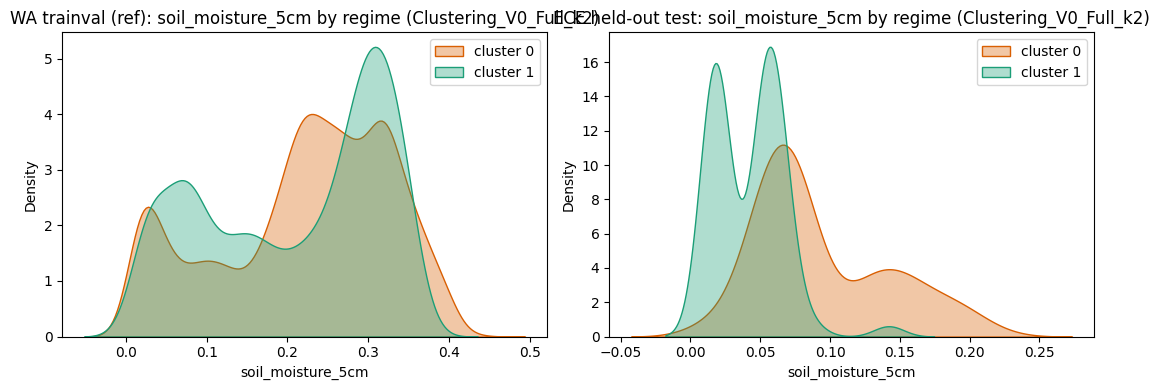


--- Share of each cluster per month ---
|   month |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|--------:|----------------------:|----------------------:|---------------------:|---------------------:|
|       1 |               nan     |               nan     |                0.766 |                0.234 |
|       2 |               nan     |               nan     |                0.779 |                0.221 |
|       3 |               nan     |               nan     |                0.733 |                0.267 |
|       4 |               nan     |               nan     |                0.714 |                0.286 |
|       5 |               nan     |               nan     |                0.714 |                0.286 |
|       6 |               nan     |               nan     |                0.712 |                0.288 |
|       7 |                 0.583 |                 0.417 |                0.714 |                0.286 |
|    

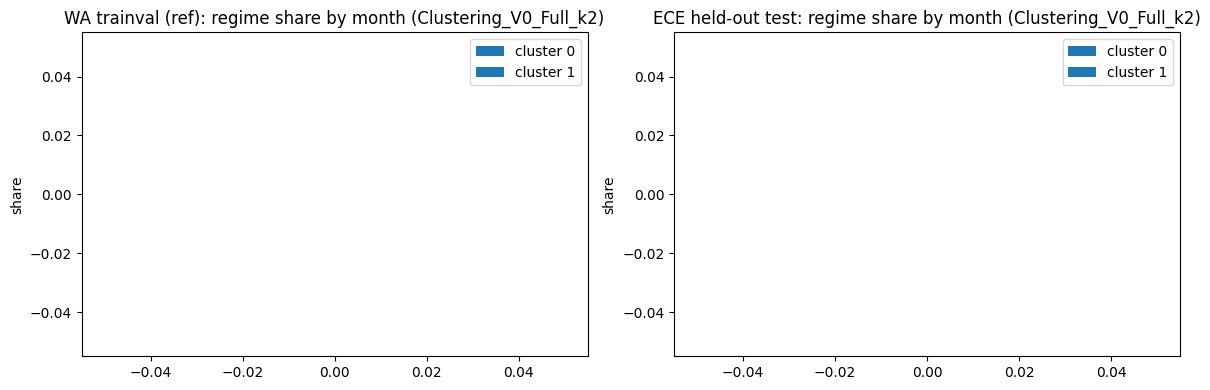


--- Share of each cluster per year ---
|   year |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |               nan     |               nan     |                0.732 |                0.268 |
|   2018 |               nan     |               nan     |                0.729 |                0.271 |
|   2019 |               nan     |               nan     |                0.736 |                0.264 |
|   2020 |               nan     |               nan     |                0.723 |                0.277 |
|   2021 |               nan     |               nan     |                0.719 |                0.281 |
|   2022 |               nan     |               nan     |                0.725 |                0.275 |
|   2026 |                 0.593 |                 0.407 |              nan     |              nan     |

--- Station co

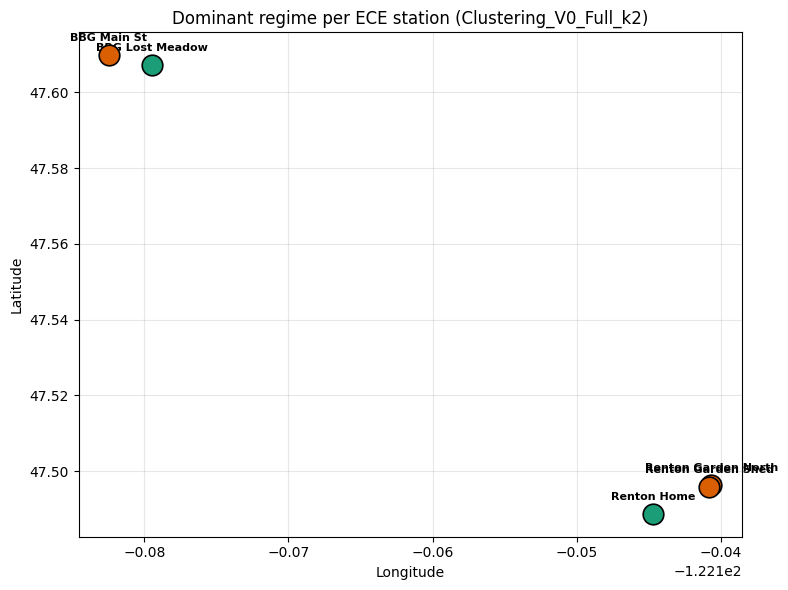


--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |             0     |            0      |             0.02  |
| G_API             |             4.941 |            4.3664 |            -0.08  |
| G_rain_sum_7d     |             1.1   |            0.8    |            -0     |
| LST_modis         |           299.702 |          299.124  |            -0.235 |
| SMAP_sm_pm_interp |             0     |            0      |             0     |
| G_DSLR            |             4     |            3      |            -0.116 |


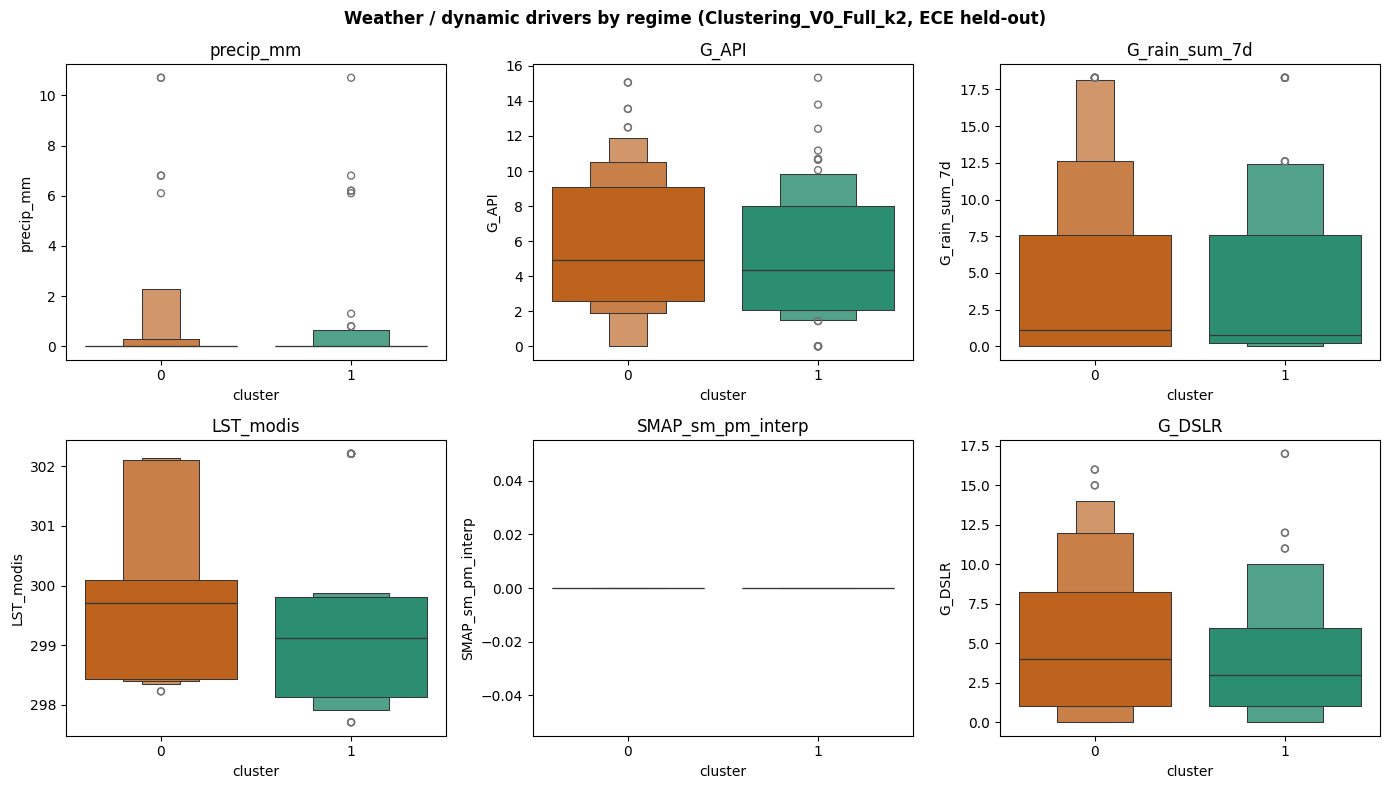


--- Static / environmental attributes per regime (ECE held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.496 |            47.607 |            -0.232 |
| longitude              |          -122.141 |          -122.18  |            -0.343 |
| elev                   |           152.514 |            40.965 |            -0.652 |
| slope                  |             4.109 |             5.181 |             0.077 |
| J_soil_texture_usda_b0 |             7     |             7     |             0     |
| J_lc_code              |            30     |            30     |            -0.193 |


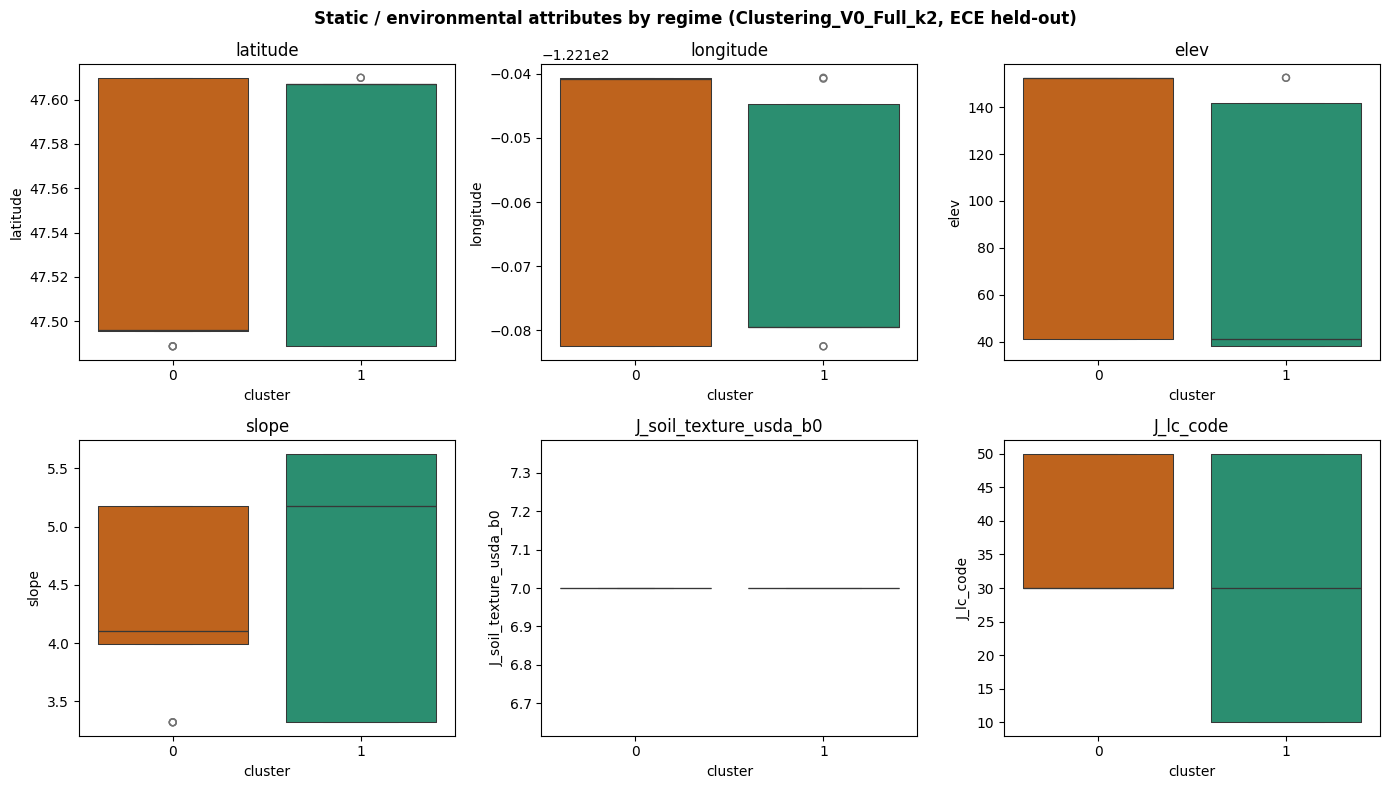


--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---
| feature                     |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:----------------------------|------------------:|------------------:|------------------:|
| J_aspect_deg                |          283      |          251      |            -0.928 |
| K_aspect_cos                |            0.225  |           -0.3256 |            -0.928 |
| lia_std_asc_deg             |            4.8608 |            4.8384 |            -0.928 |
| K_aspect_sin                |           -0.9744 |           -0.9455 |             0.906 |
| aspect                      |          170.467  |          177.955  |             0.895 |
| J_clay_wfrac_b100           |           25      |           22      |            -0.343 |
| s2_b11                      |            0.189  |            0.1841 |            -0.333 |
| V_ema_F_NDVI_kobs30         |            0.5574 |            0.5079 |     

In [4]:
interpret_regimes("Clustering_V0_Full_k2")

### 3.2 Clustering_Dynamic_k2

We evaluate the dynamic 3-feature clustering router (`SMAP_sm_pm_interp_lag1`, `G_API`, `LST_modis`) on the in-situ ECE stations.



Strategy: Clustering_Dynamic_k2 (Evaluated on 5 In-Situ ECE Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7974 (54.6%)  |  ECE held-out =   150 (100.0%)
cluster 1: WA trainval =  6634 (45.4%)  |  ECE held-out =     0 ( 0.0%)


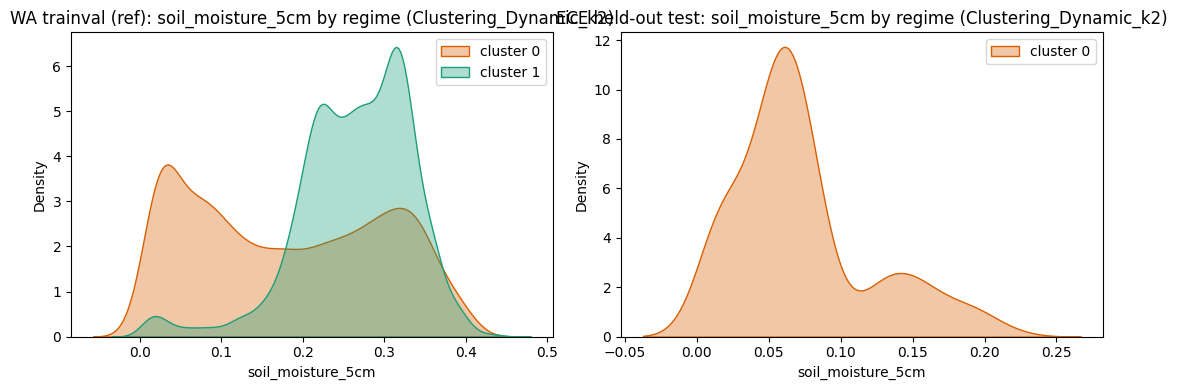


--- Share of each cluster per month ---
|   month |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|--------:|----------------------:|----------------------:|---------------------:|---------------------:|
|       1 |                   nan |                   nan |                0.012 |                0.988 |
|       2 |                   nan |                   nan |                0.06  |                0.94  |
|       3 |                   nan |                   nan |                0.309 |                0.691 |
|       4 |                   nan |                   nan |                0.471 |                0.529 |
|       5 |                   nan |                   nan |                0.847 |                0.153 |
|       6 |                   nan |                   nan |                0.952 |                0.048 |
|       7 |                     1 |                     0 |                1     |                0     |
|    

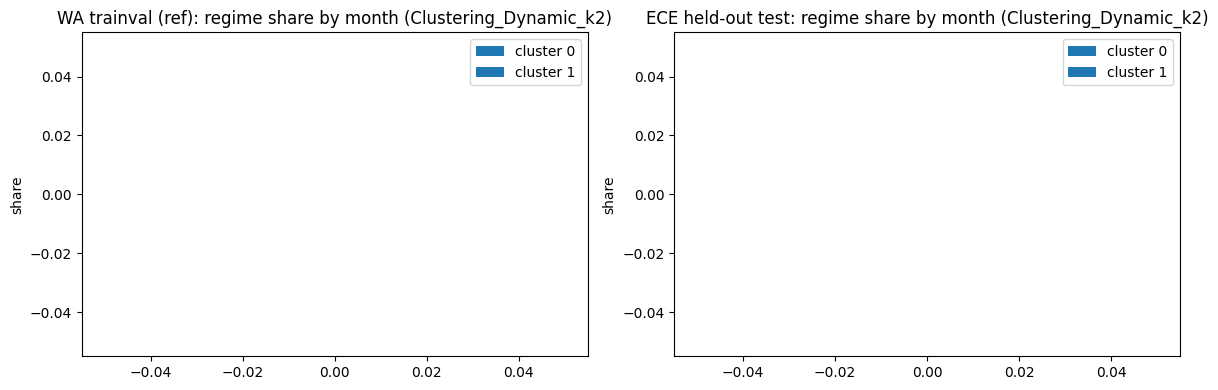


--- Share of each cluster per year ---
|   year |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                   nan |                   nan |                0.531 |                0.469 |
|   2018 |                   nan |                   nan |                0.573 |                0.427 |
|   2019 |                   nan |                   nan |                0.567 |                0.433 |
|   2020 |                   nan |                   nan |                0.556 |                0.444 |
|   2021 |                   nan |                   nan |                0.552 |                0.448 |
|   2022 |                   nan |                   nan |                0.493 |                0.507 |
|   2026 |                     1 |                     0 |              nan     |              nan     |

--- Station co

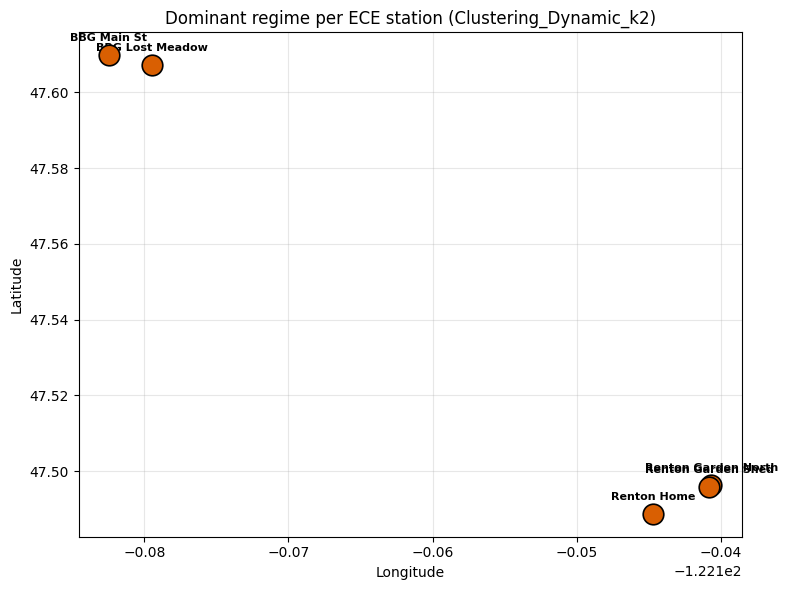


--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |               nan |               nan |
| G_API             |            4.8515 |               nan |               nan |
| G_rain_sum_7d     |            0.95   |               nan |               nan |
| LST_modis         |          299.439  |               nan |               nan |
| SMAP_sm_pm_interp |            0      |               nan |               nan |
| G_DSLR            |            4      |               nan |               nan |


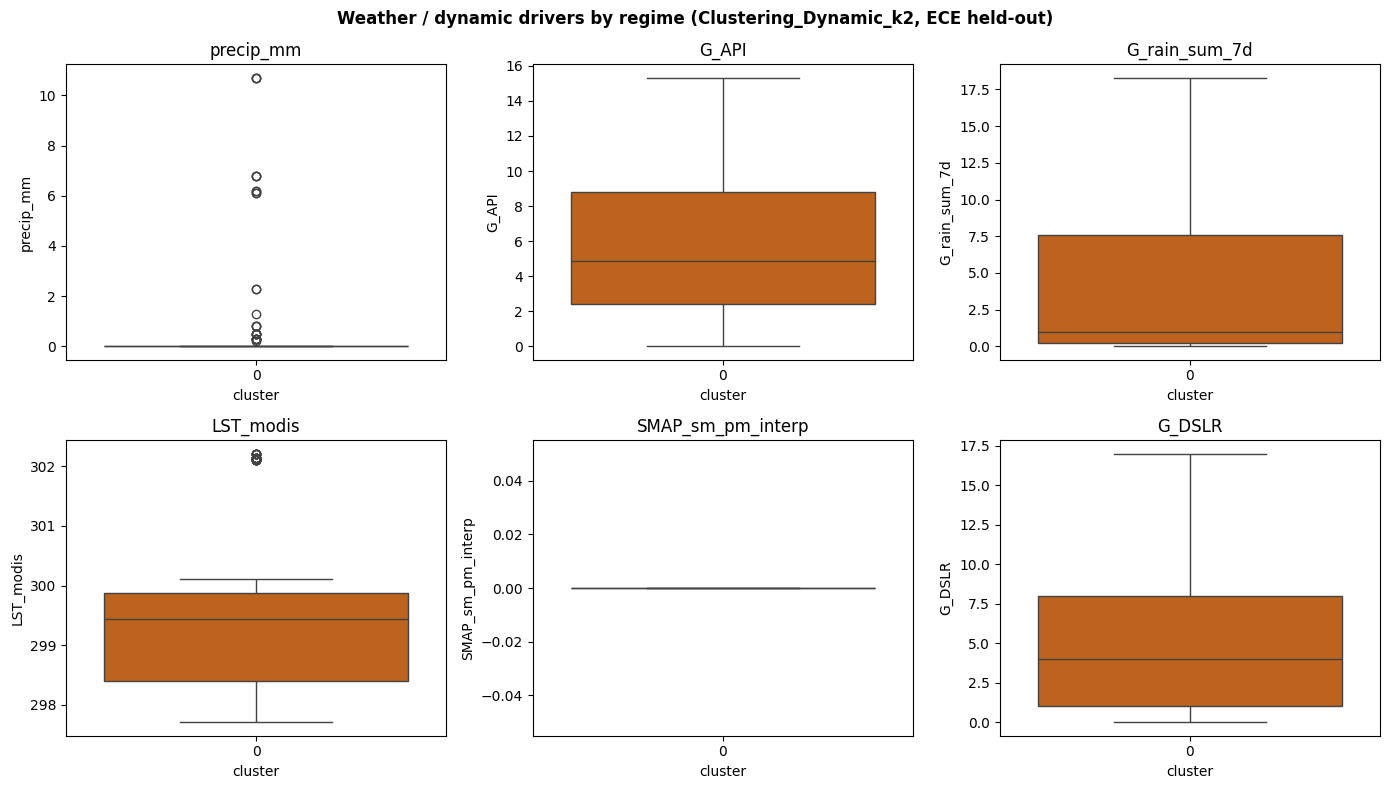


--- Static / environmental attributes per regime (ECE held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.496 |               nan |               nan |
| longitude              |          -122.145 |               nan |               nan |
| elev                   |           141.637 |               nan |               nan |
| slope                  |             4.109 |               nan |               nan |
| J_soil_texture_usda_b0 |             7     |               nan |               nan |
| J_lc_code              |            30     |               nan |               nan |


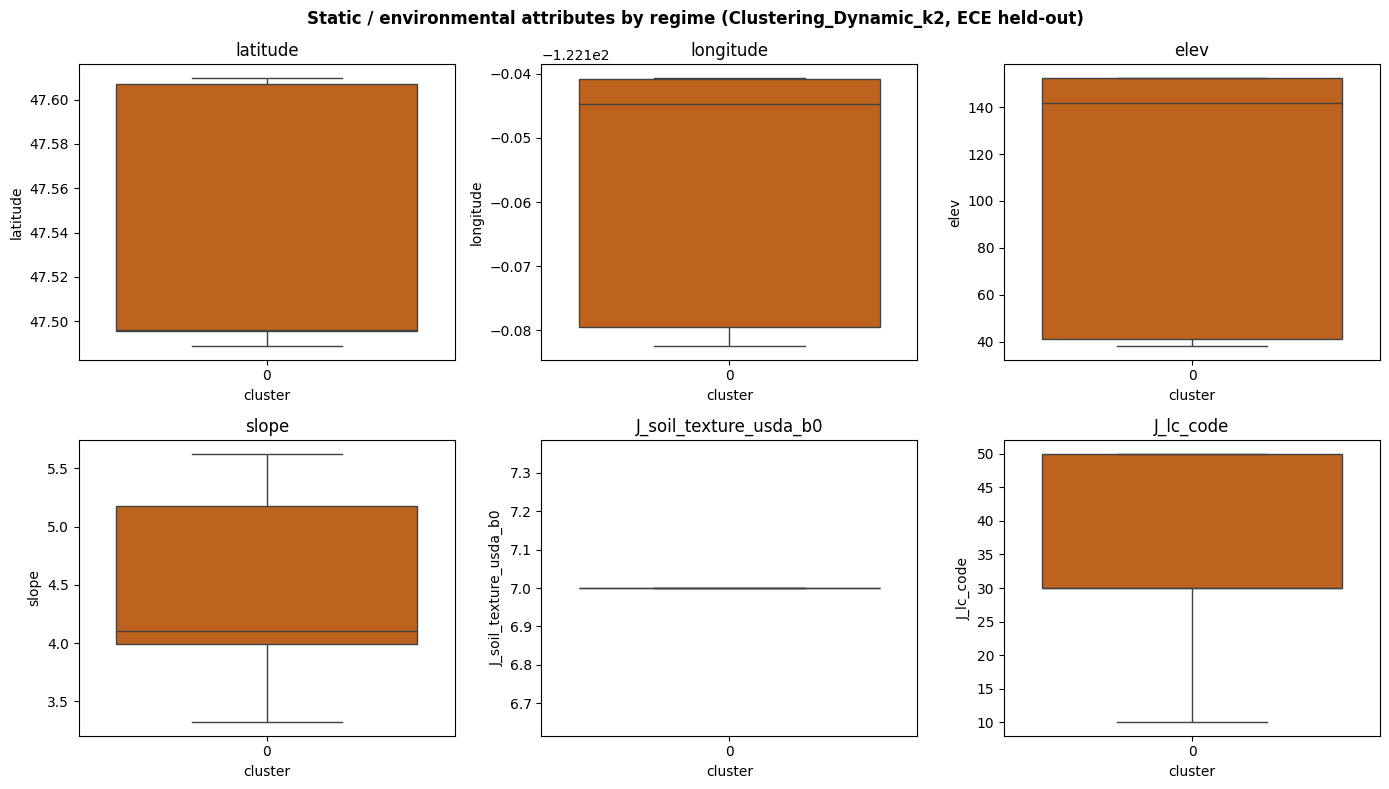


--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---
No separating features (single cluster assigned across all rows).

Saved regime_profile_summary_Clustering_Dynamic_k2.csv, regime_station_composition_Clustering_Dynamic_k2.csv, regime_top_features_Clustering_Dynamic_k2.csv


In [5]:
interpret_regimes("Clustering_Dynamic_k2")

### 3.3 Seasonal_Binary_k2

We evaluate the deterministic calendar-based split (May–Oct dry vs Nov–Apr wet) on the in-situ ECE stations.



Strategy: Seasonal_Binary_k2 (Evaluated on 5 In-Situ ECE Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7559 (51.7%)  |  ECE held-out =   150 (100.0%)
cluster 1: WA trainval =  7049 (48.3%)  |  ECE held-out =     0 ( 0.0%)


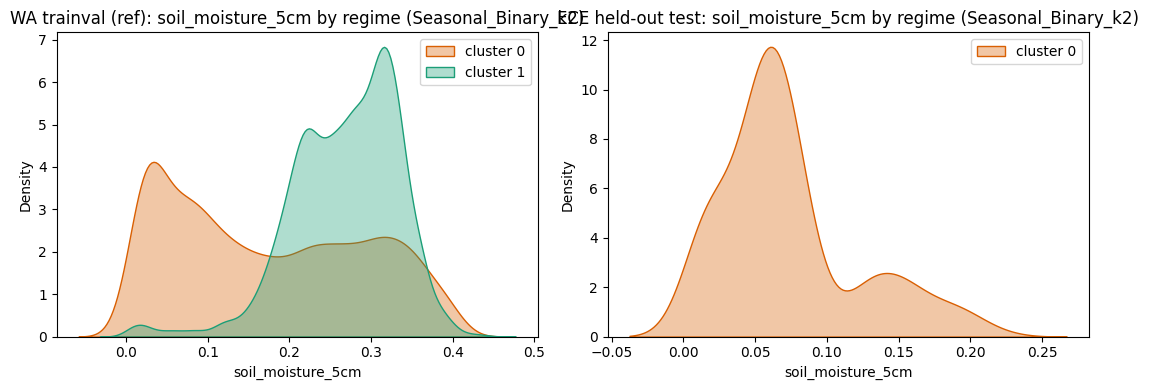


--- Share of each cluster per month ---
|   month |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|--------:|----------------------:|----------------------:|---------------------:|---------------------:|
|       1 |                   nan |                   nan |                    0 |                    1 |
|       2 |                   nan |                   nan |                    0 |                    1 |
|       3 |                   nan |                   nan |                    0 |                    1 |
|       4 |                   nan |                   nan |                    0 |                    1 |
|       5 |                   nan |                   nan |                    1 |                    0 |
|       6 |                   nan |                   nan |                    1 |                    0 |
|       7 |                     1 |                     0 |                    1 |                    0 |
|    

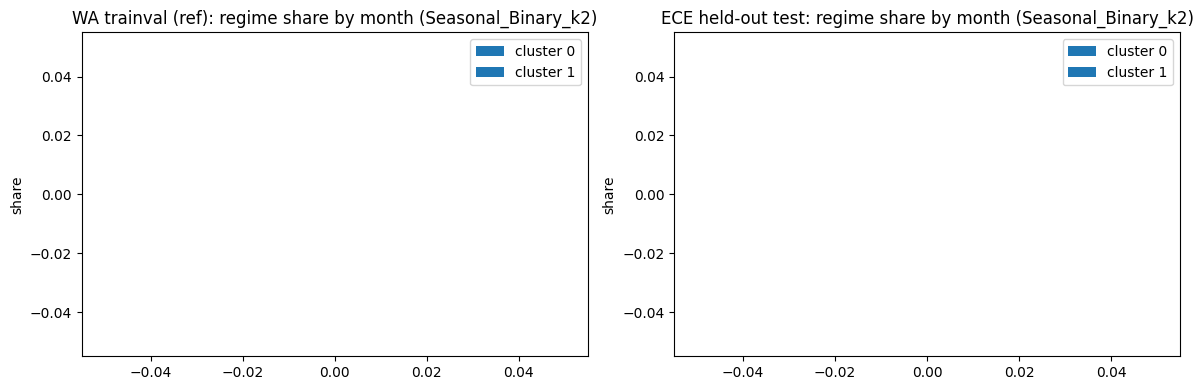


--- Share of each cluster per year ---
|   year |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                   nan |                   nan |                0.521 |                0.479 |
|   2018 |                   nan |                   nan |                0.518 |                0.482 |
|   2019 |                   nan |                   nan |                0.531 |                0.469 |
|   2020 |                   nan |                   nan |                0.509 |                0.491 |
|   2021 |                   nan |                   nan |                0.514 |                0.486 |
|   2022 |                   nan |                   nan |                0.512 |                0.488 |
|   2026 |                     1 |                     0 |              nan     |              nan     |

--- Station co

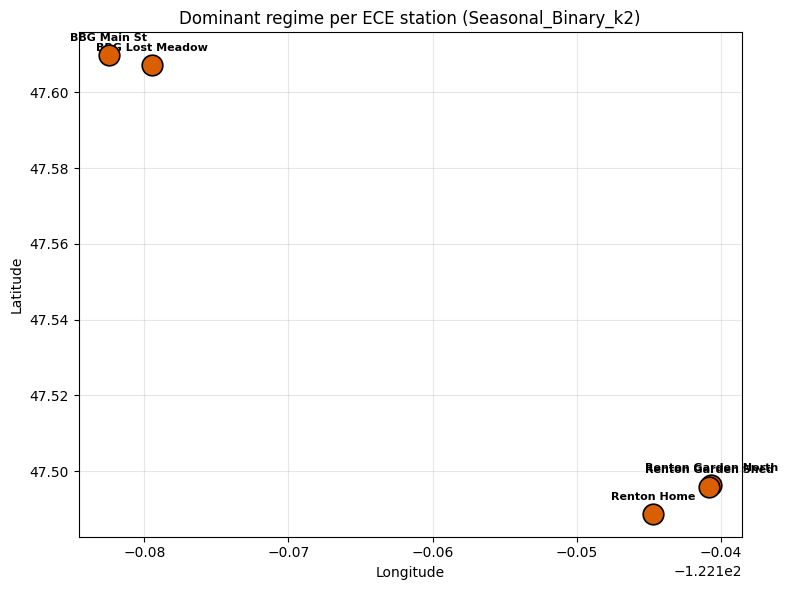


--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |               nan |               nan |
| G_API             |            4.8515 |               nan |               nan |
| G_rain_sum_7d     |            0.95   |               nan |               nan |
| LST_modis         |          299.439  |               nan |               nan |
| SMAP_sm_pm_interp |            0      |               nan |               nan |
| G_DSLR            |            4      |               nan |               nan |


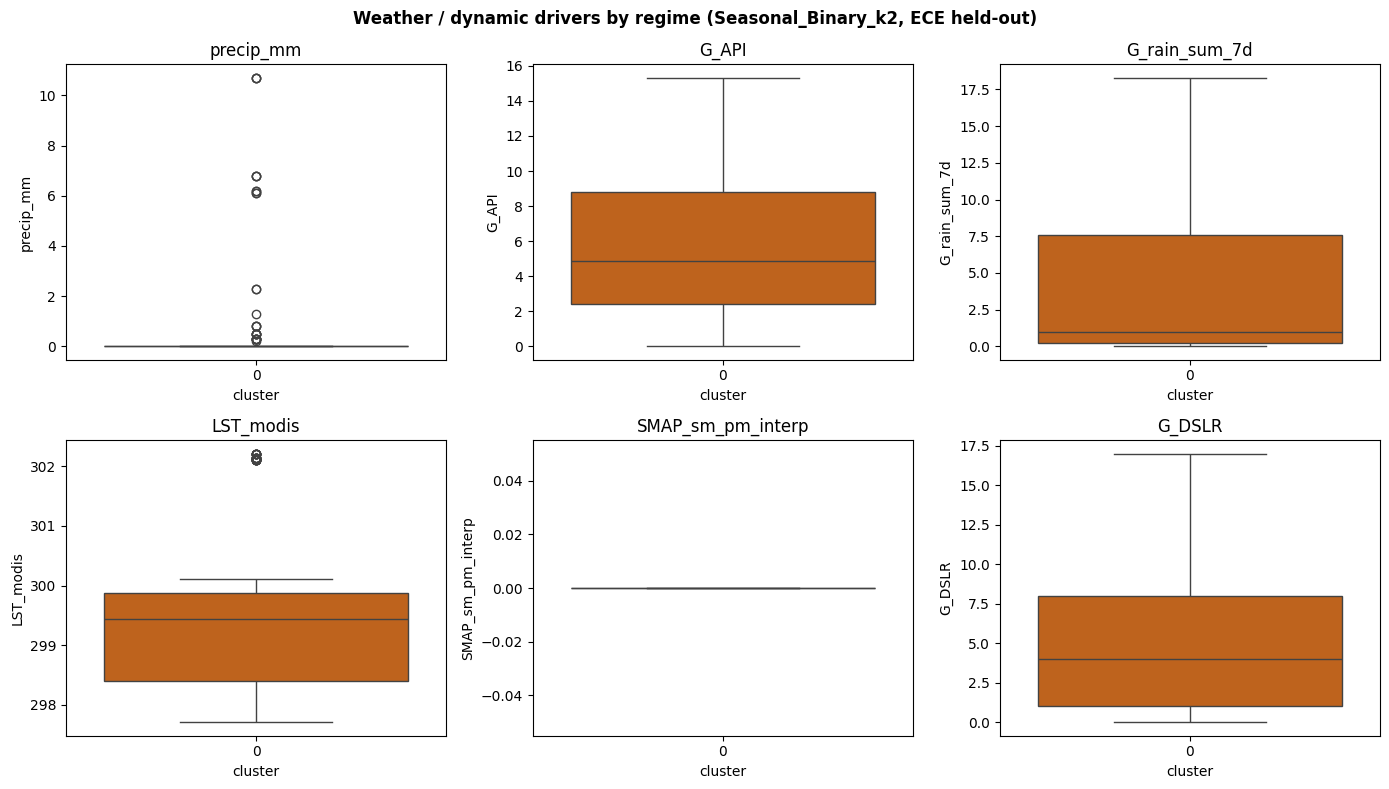


--- Static / environmental attributes per regime (ECE held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.496 |               nan |               nan |
| longitude              |          -122.145 |               nan |               nan |
| elev                   |           141.637 |               nan |               nan |
| slope                  |             4.109 |               nan |               nan |
| J_soil_texture_usda_b0 |             7     |               nan |               nan |
| J_lc_code              |            30     |               nan |               nan |


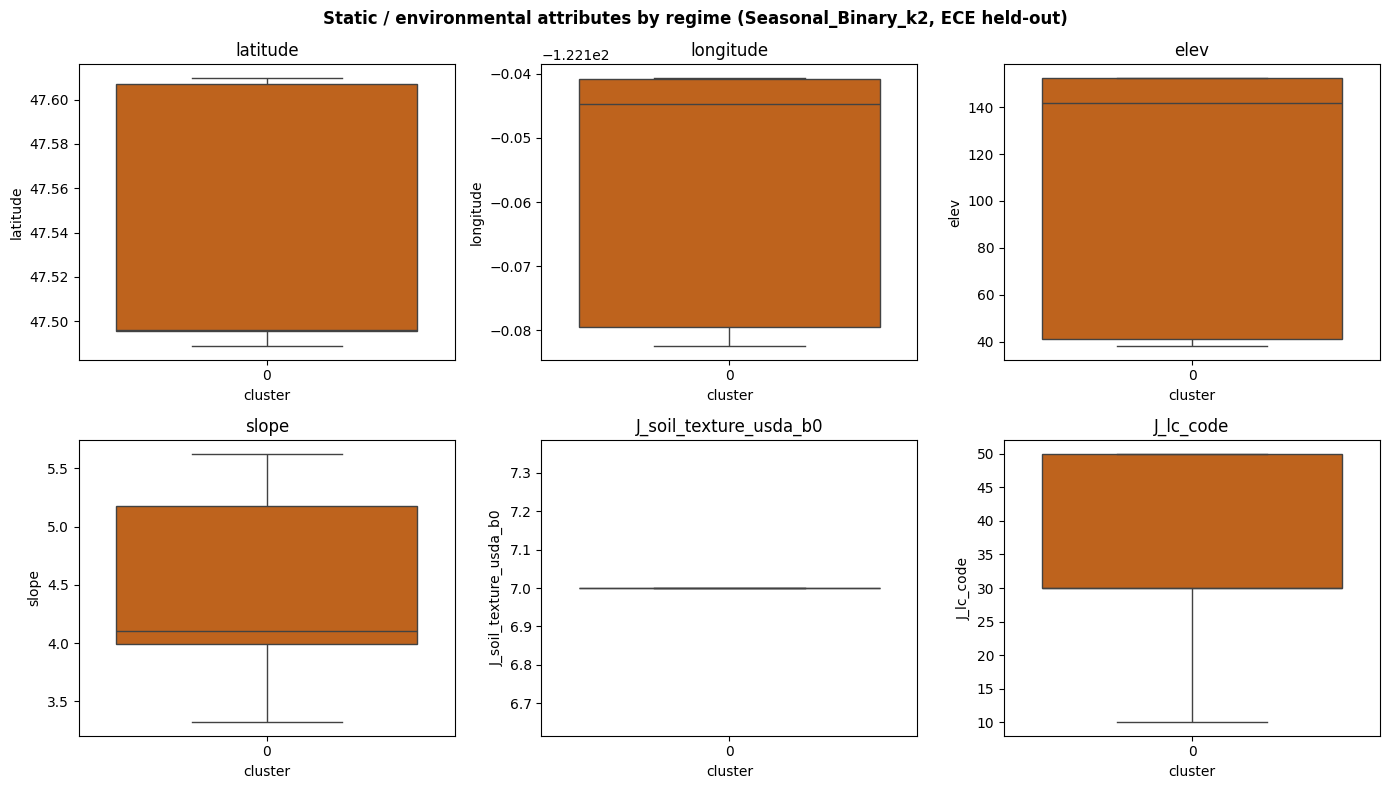


--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---
No separating features (single cluster assigned across all rows).

Saved regime_profile_summary_Seasonal_Binary_k2.csv, regime_station_composition_Seasonal_Binary_k2.csv, regime_top_features_Seasonal_Binary_k2.csv


In [6]:
interpret_regimes("Seasonal_Binary_k2")

### 3.4 Univariate_G_API_k2

We evaluate the antecedent precipitation index threshold router (`G_API` median threshold) on the in-situ ECE stations.



Strategy: Univariate_G_API_k2 (Evaluated on 5 In-Situ ECE Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7304 (50.0%)  |  ECE held-out =   150 (100.0%)
cluster 1: WA trainval =  7304 (50.0%)  |  ECE held-out =     0 ( 0.0%)


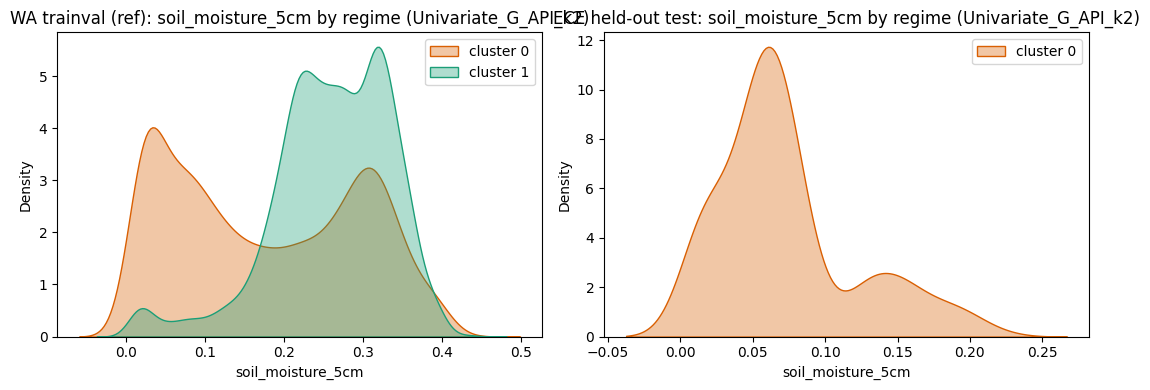


--- Share of each cluster per month ---
|   month |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|--------:|----------------------:|----------------------:|---------------------:|---------------------:|
|       1 |                   nan |                   nan |                0.163 |                0.837 |
|       2 |                   nan |                   nan |                0.184 |                0.816 |
|       3 |                   nan |                   nan |                0.327 |                0.673 |
|       4 |                   nan |                   nan |                0.378 |                0.622 |
|       5 |                   nan |                   nan |                0.564 |                0.436 |
|       6 |                   nan |                   nan |                0.628 |                0.372 |
|       7 |                     1 |                     0 |                0.908 |                0.092 |
|    

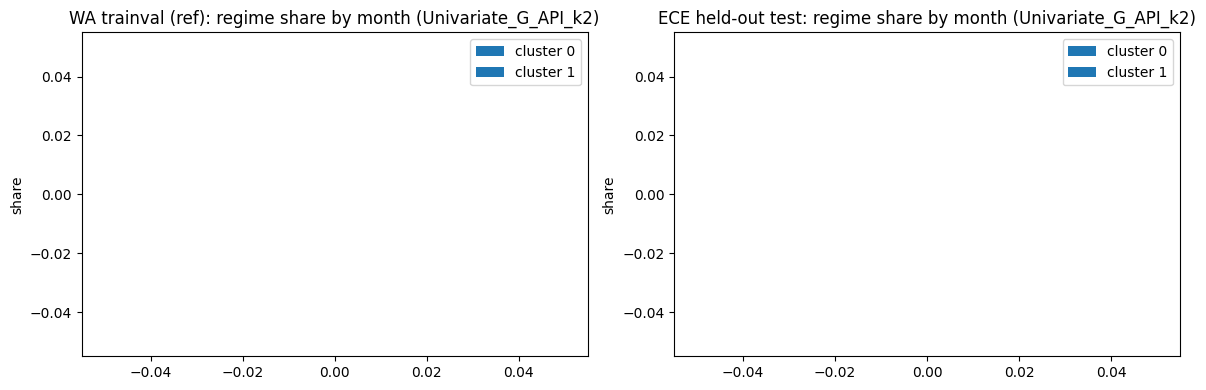


--- Share of each cluster per year ---
|   year |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                   nan |                   nan |                0.465 |                0.535 |
|   2018 |                   nan |                   nan |                0.527 |                0.473 |
|   2019 |                   nan |                   nan |                0.546 |                0.454 |
|   2020 |                   nan |                   nan |                0.472 |                0.528 |
|   2021 |                   nan |                   nan |                0.527 |                0.473 |
|   2022 |                   nan |                   nan |                0.461 |                0.539 |
|   2026 |                     1 |                     0 |              nan     |              nan     |

--- Station co

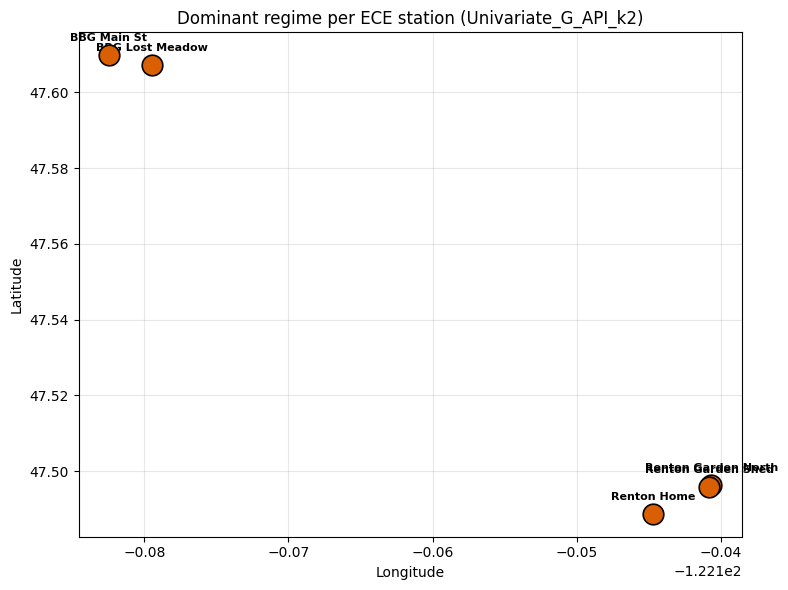


--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |               nan |               nan |
| G_API             |            4.8515 |               nan |               nan |
| G_rain_sum_7d     |            0.95   |               nan |               nan |
| LST_modis         |          299.439  |               nan |               nan |
| SMAP_sm_pm_interp |            0      |               nan |               nan |
| G_DSLR            |            4      |               nan |               nan |


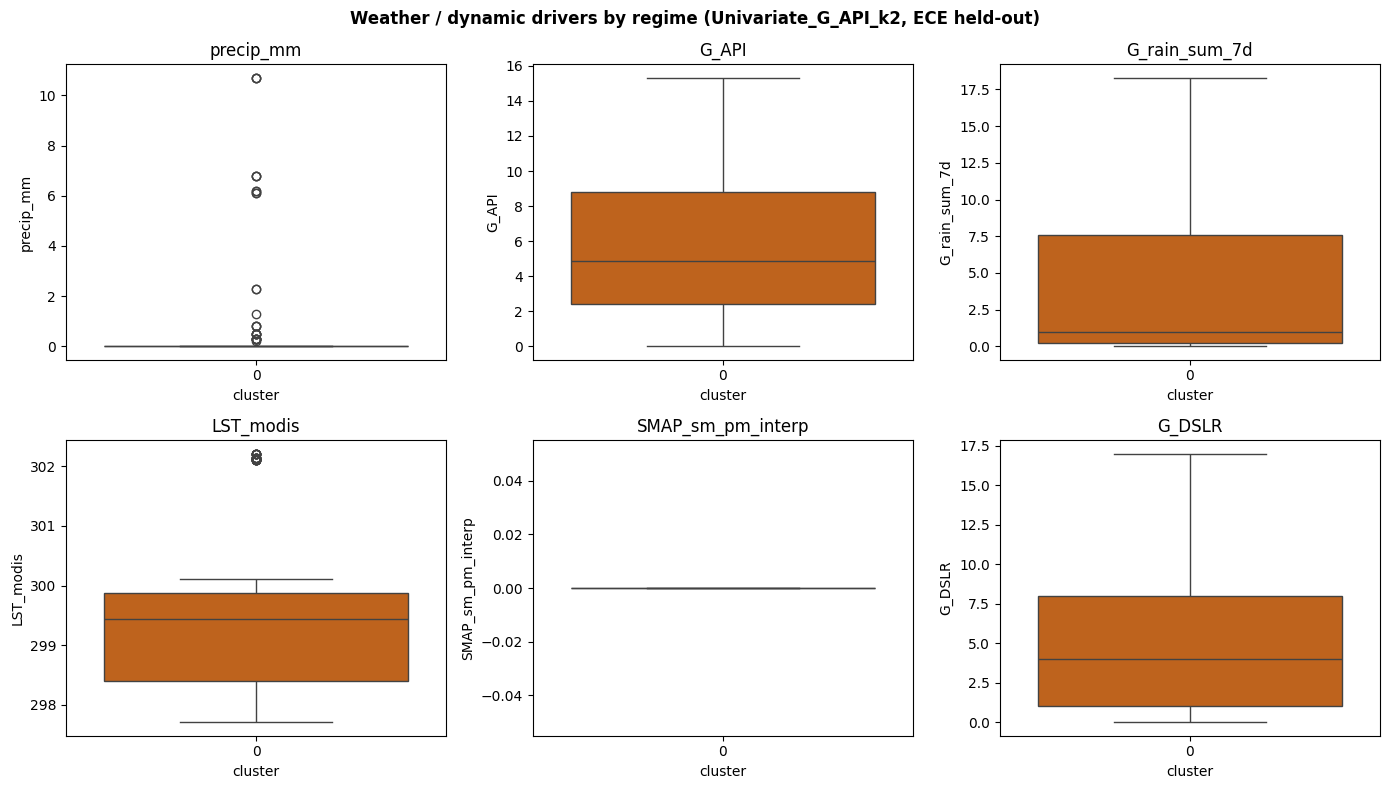


--- Static / environmental attributes per regime (ECE held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.496 |               nan |               nan |
| longitude              |          -122.145 |               nan |               nan |
| elev                   |           141.637 |               nan |               nan |
| slope                  |             4.109 |               nan |               nan |
| J_soil_texture_usda_b0 |             7     |               nan |               nan |
| J_lc_code              |            30     |               nan |               nan |


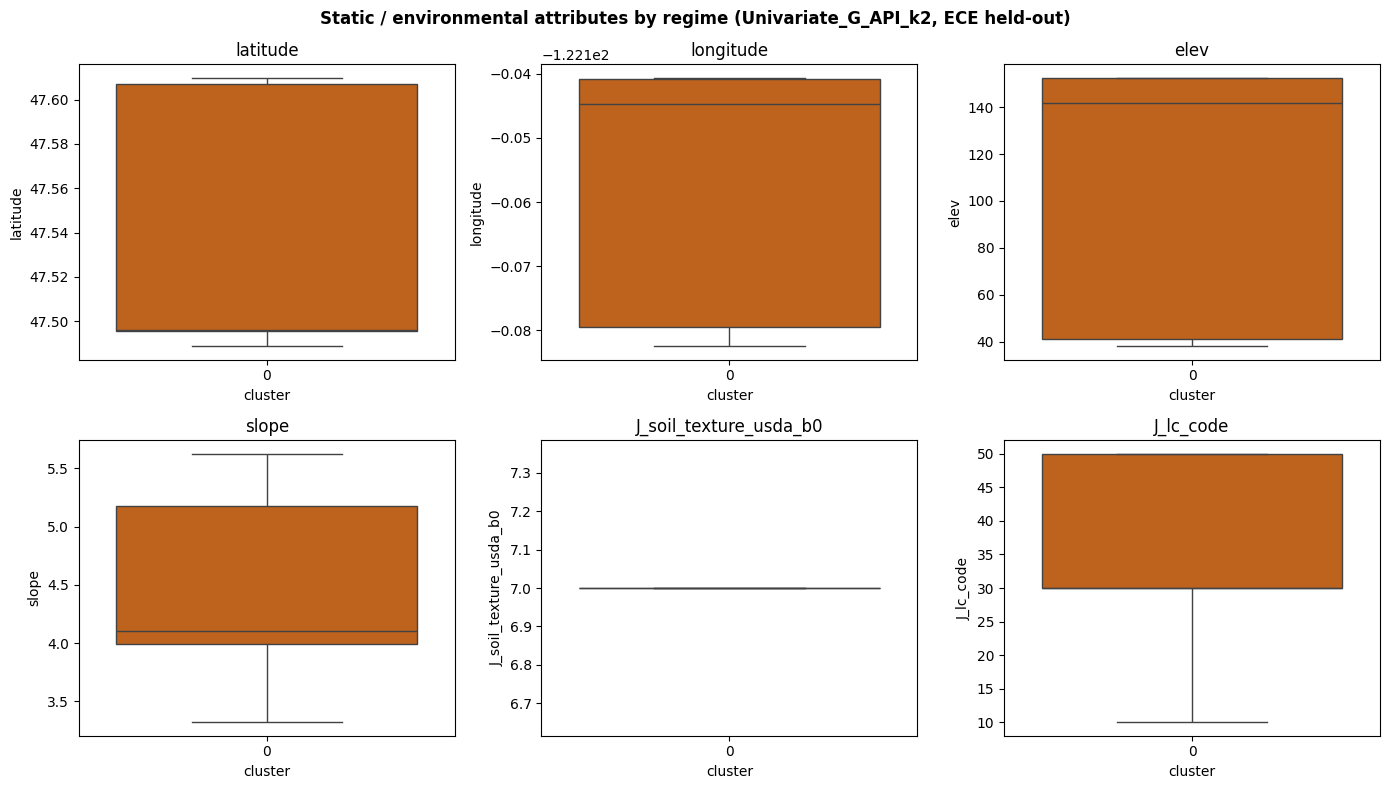


--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---
No separating features (single cluster assigned across all rows).

Saved regime_profile_summary_Univariate_G_API_k2.csv, regime_station_composition_Univariate_G_API_k2.csv, regime_top_features_Univariate_G_API_k2.csv


In [7]:
interpret_regimes("Univariate_G_API_k2")

### 3.5 Trained_Gating_k2

We evaluate the supervised classifier trained on `soil_moisture_5cm < 0.16` on the in-situ ECE stations.



Strategy: Trained_Gating_k2 (Evaluated on 5 In-Situ ECE Stations)

--- Regime sizes ---
cluster 0: WA trainval =  4181 (28.6%)  |  ECE held-out =   120 (80.0%)
cluster 1: WA trainval = 10427 (71.4%)  |  ECE held-out =    30 (20.0%)


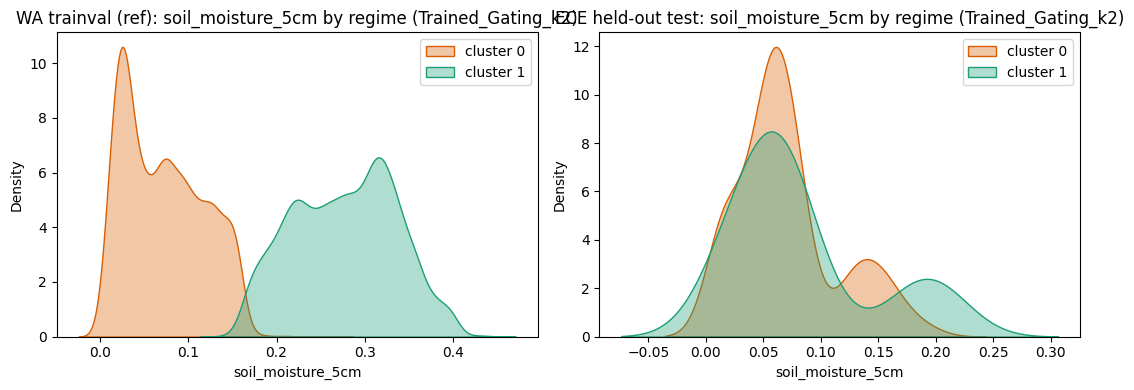


--- Share of each cluster per month ---
|   month |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|--------:|----------------------:|----------------------:|---------------------:|---------------------:|
|       1 |                 nan   |                 nan   |                0.01  |                0.99  |
|       2 |                 nan   |                 nan   |                0     |                1     |
|       3 |                 nan   |                 nan   |                0     |                1     |
|       4 |                 nan   |                 nan   |                0.001 |                0.999 |
|       5 |                 nan   |                 nan   |                0.089 |                0.911 |
|       6 |                 nan   |                 nan   |                0.232 |                0.768 |
|       7 |                   0.5 |                   0.5 |                0.569 |                0.431 |
|    

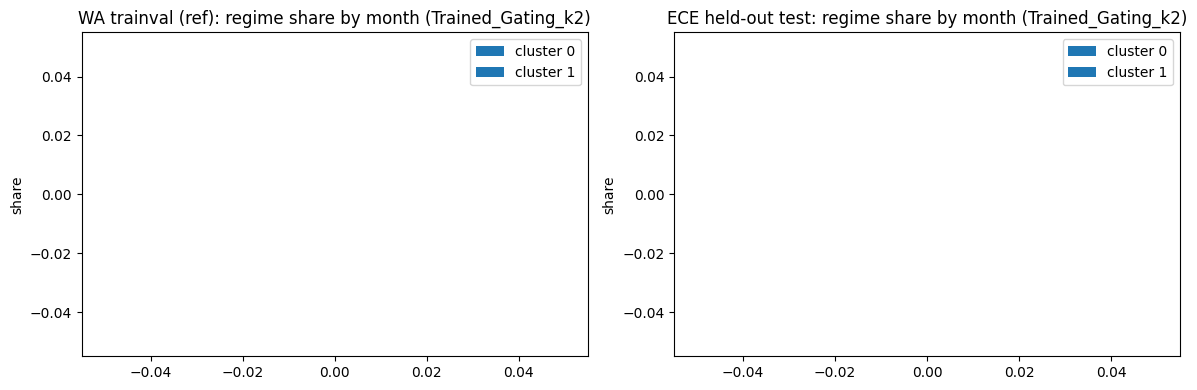


--- Share of each cluster per year ---
|   year |   ('ECE held-out', 0) |   ('ECE held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 nan   |                 nan   |                0.316 |                0.684 |
|   2018 |                 nan   |                 nan   |                0.351 |                0.649 |
|   2019 |                 nan   |                 nan   |                0.216 |                0.784 |
|   2020 |                 nan   |                 nan   |                0.243 |                0.757 |
|   2021 |                 nan   |                 nan   |                0.29  |                0.71  |
|   2022 |                 nan   |                 nan   |                0.302 |                0.698 |
|   2026 |                   0.8 |                   0.2 |              nan     |              nan     |

--- Station co

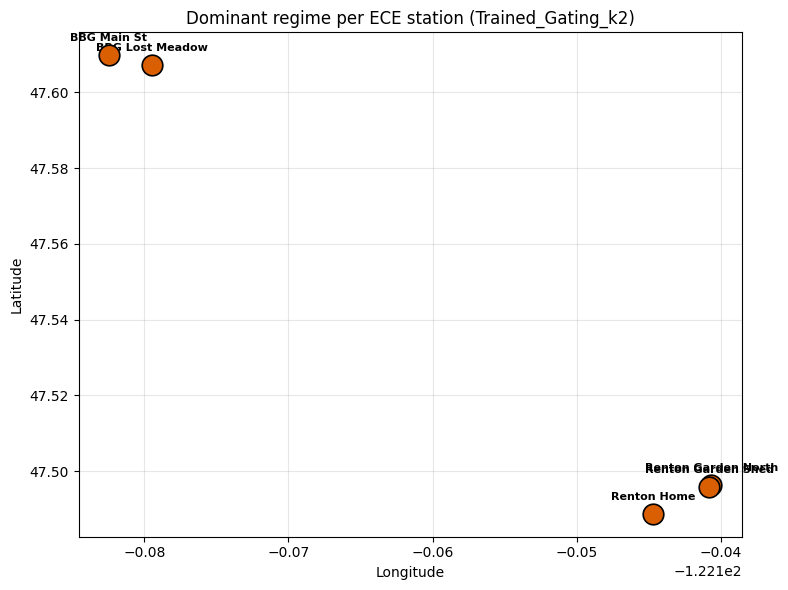


--- Weather / dynamic drivers per regime (ECE held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |            0      |             0.121 |
| G_API             |            4.8515 |            2.4705 |            -0.27  |
| G_rain_sum_7d     |            0.95   |            3.05   |            -0.15  |
| LST_modis         |          299.124  |          302.104  |             0.818 |
| SMAP_sm_pm_interp |            0      |            0      |             0     |
| G_DSLR            |            4      |            0      |            -0.762 |


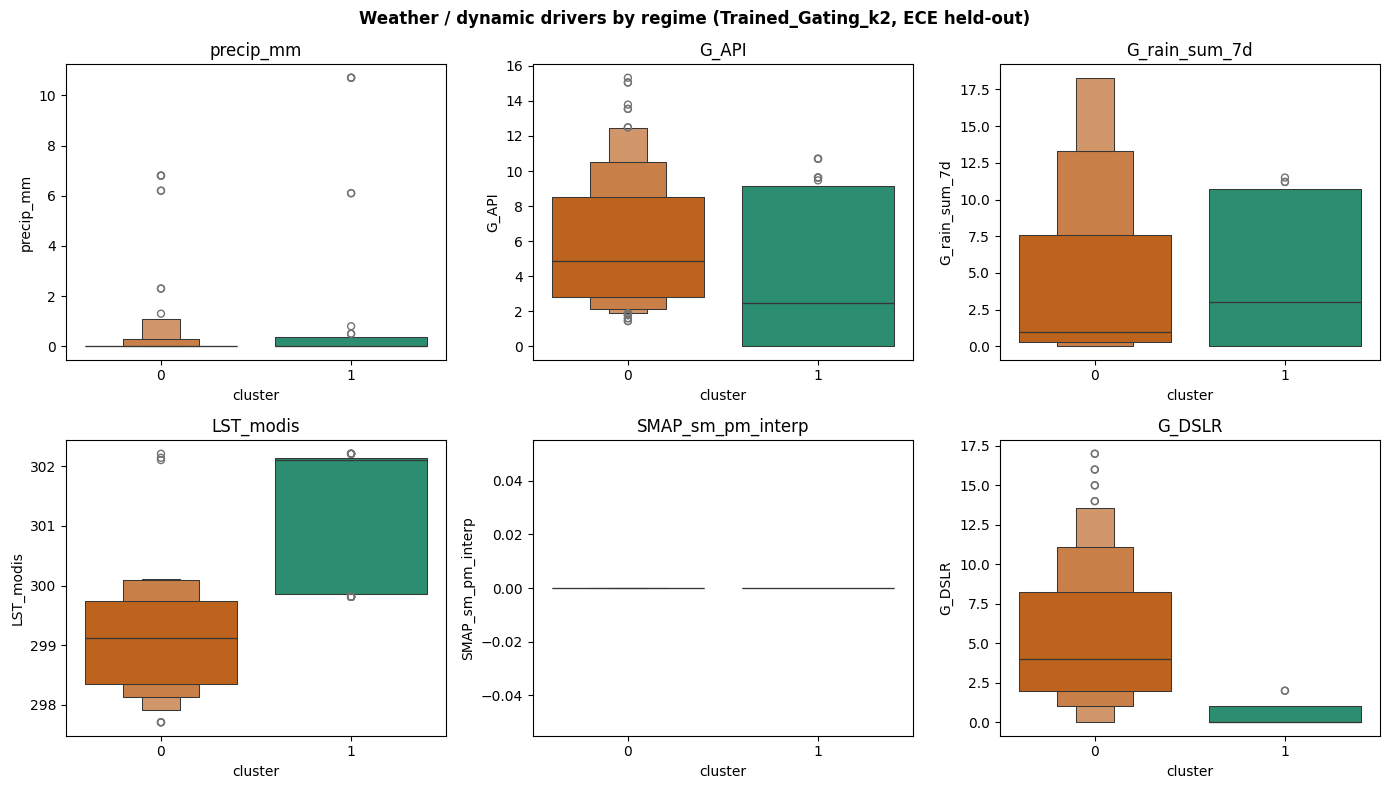


--- Static / environmental attributes per regime (ECE held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.496 |            47.496 |                 0 |
| longitude              |          -122.145 |          -122.145 |                 0 |
| elev                   |           141.637 |           141.637 |                 0 |
| slope                  |             4.109 |             4.109 |                 0 |
| J_soil_texture_usda_b0 |             7     |             7     |                 0 |
| J_lc_code              |            30     |            30     |                 0 |


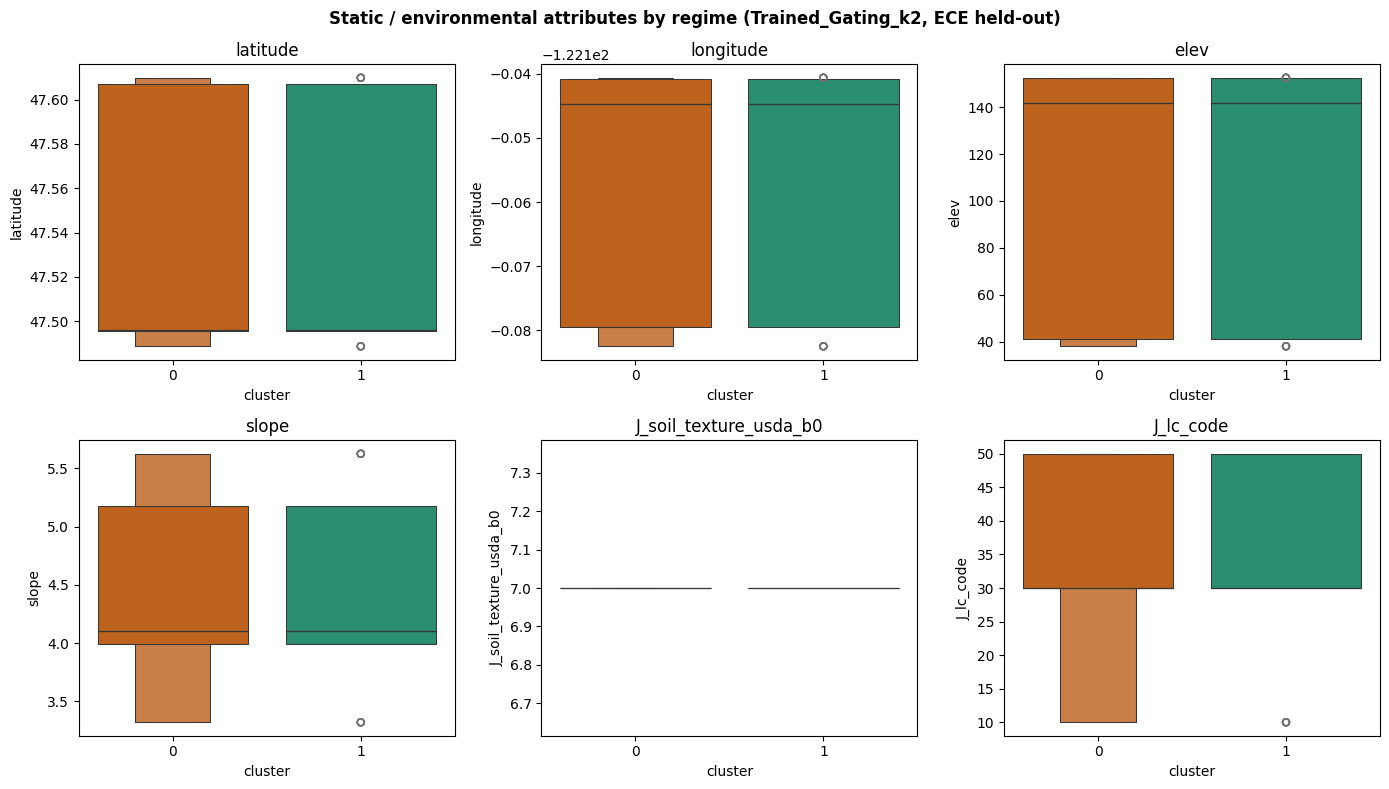


--- Top 15 V0 features separating the regimes (ECE held-out; r > 0 => higher in cluster 1) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| V_ema_G_API_kobs30     |            4.4161 |            0.1968 |            -0.997 |
| D_sa_LST_modis         |            0.4147 |            4.1635 |             0.958 |
| D_z_E_SAR_ratio        |            0.7362 |            1.4105 |             0.705 |
| D_sa_F_NDMI            |           -0.0776 |           -0.0956 |            -0.548 |
| V_ema_LST_modis_kobs30 |          299.956  |          302.104  |             0.532 |
| s2_b11                 |            0.1833 |            0.1883 |             0.465 |
| E_SAR_ratio            |            5.2703 |            5.4842 |             0.445 |
| V_ema_F_NDVI_kobs30    |            0.5129 |            0.5354 |             0.325 |
| s2_b8                  |        

In [8]:
interpret_regimes("Trained_Gating_k2")

### 3.6 Geographic & physical deep dive: why the Clustering_V0_Full_k2 regimes are physical on ECE in-situ stations

We conduct a deep geographic, micro-siting, and physical characterization of the winning `Clustering_V0_Full_k2` router on the 5 ECE in-situ sensor stations in King County, Washington.


In [9]:
"""3.6.1 Per-station physical profile: cluster assignment + climate / soil / terrain / satellite attributes."""
static_wa = pd.read_csv(SPLIT_DIR_WA / "station_static_features.csv")
static_ece = pd.read_csv(SPLIT_DIR_ECE / "station_static_features.csv")
static_all = pd.concat([static_wa, static_ece], ignore_index=True).drop_duplicates("station_id")

lbl_ece_v0 = labels[("Clustering_V0_Full_k2", "test")]

BIOCLIM_LABELS = {
    "J_bio_bio01": "BIO01_annual_mean_temp_C",
    "J_bio_bio04": "BIO04_temp_seasonality_sd",
    "J_bio_bio05": "BIO05_max_temp_warmest_month_C",
    "J_bio_bio06": "BIO06_min_temp_coldest_month_C",
    "J_bio_bio07": "BIO07_temp_annual_range_C",
    "J_bio_bio12": "BIO12_annual_precip_mm",
    "J_bio_bio13": "BIO13_precip_wettest_month_mm",
    "J_bio_bio14": "BIO14_precip_driest_month_mm",
    "J_bio_bio15": "BIO15_precip_seasonality_CV",
    "J_bio_bio16": "BIO16_precip_wettest_quarter_mm",
    "J_bio_bio17": "BIO17_precip_driest_quarter_mm",
}

clim_cols = ["SMAP_sm_pm_interp", "F_NDVI", "F_NDMI", "F_MSI", "LST_modis"]
clim_ece = ece_test.groupby("station_id")[clim_cols].mean().add_prefix("clim_")

rows = []
for sid, grp in ece_test.groupby("station_id"):
    mask = (ece_test["station_id"] == sid).to_numpy()
    cluster_shares = [(lbl_ece_v0[mask] == c).mean() for c in [0, 1]]
    dominant_cluster = int(np.argmax(cluster_shares))
    purity = float(np.max(cluster_shares))
    s = static_all[static_all["station_id"] == sid].iloc[0]
    r = {
        "station_id": sid,
        "cluster": dominant_cluster,
        "purity": round(purity, 3),
        "share_c1": round(float(cluster_shares[1]), 3),
        "longitude": round(float(s["longitude"]), 4),
        "latitude": round(float(s["latitude"]), 4),
        "elev": round(float(s["J_elev_m"]), 2),
        "slope": round(float(s["J_slope_deg"]), 2),
        "aspect": round(float(s["J_aspect_deg"]), 2),
    }
    for jcol, label in BIOCLIM_LABELS.items():
        val = float(s[jcol])
        r[label] = round(val / 10.0, 2) if label.endswith("_C") else round(val, 1)
    for col in ["J_clay_wfrac_b0", "J_clay_wfrac_b30", "J_clay_wfrac_b100", "J_sand_wfrac_b0",
                "J_sand_wfrac_b100", "J_soil_texture_usda_b0", "K_sand_clay_ratio_b0",
                "K_aspect_cos", "J_lc_code"]:
        r[col] = round(float(s[col]), 3)
    r["landcover_label"] = str(s["landcover_label"])
    for col in clim_cols:
        r[f"clim_{col}"] = round(float(clim_ece.loc[sid, f"clim_{col}"]), 4)
    rows.append(r)

df_profile = pd.DataFrame(rows).sort_values(["cluster", "longitude"], ascending=[True, False])
df_profile.to_csv(EXP_DIR / "v0full_station_physical_profile.csv", index=False)
print(df_profile.to_markdown(index=False))
print(f"\nSaved v0full_station_physical_profile.csv ({len(df_profile)} stations)")


| station_id              |   cluster |   purity |   share_c1 |   longitude |   latitude |   elev |   slope |   aspect |   BIO01_annual_mean_temp_C |   BIO04_temp_seasonality_sd |   BIO05_max_temp_warmest_month_C |   BIO06_min_temp_coldest_month_C |   BIO07_temp_annual_range_C |   BIO12_annual_precip_mm |   BIO13_precip_wettest_month_mm |   BIO14_precip_driest_month_mm |   BIO15_precip_seasonality_CV |   BIO16_precip_wettest_quarter_mm |   BIO17_precip_driest_quarter_mm |   J_clay_wfrac_b0 |   J_clay_wfrac_b30 |   J_clay_wfrac_b100 |   J_sand_wfrac_b0 |   J_sand_wfrac_b100 |   J_soil_texture_usda_b0 |   K_sand_clay_ratio_b0 |   K_aspect_cos |   J_lc_code | landcover_label   |   clim_SMAP_sm_pm_interp |   clim_F_NDVI |   clim_F_NDMI |   clim_F_MSI |   clim_LST_modis |
|:------------------------|----------:|---------:|-----------:|------------:|-----------:|-------:|--------:|---------:|---------------------------:|----------------------------:|---------------------------------:|--------

### 3.6.2 Physiographic context — Washington State station map and King County ECE sensor network

We map the in-situ ECE stations alongside the Washington reference stations across Washington State topography and King County micro-geography using Esri World_Shaded_Relief.


Saved v0full_station_map.png


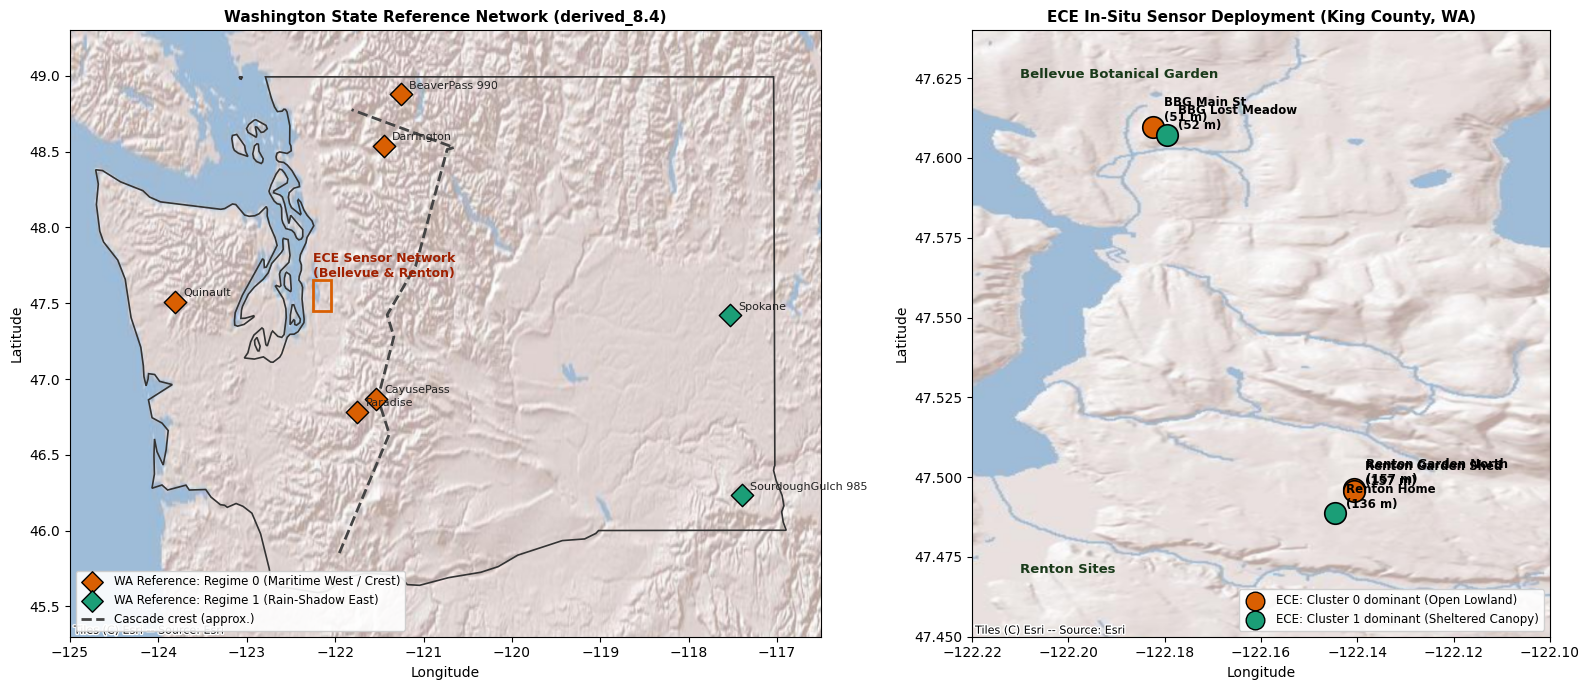

In [10]:
"""3.6.2b Washington State & King County ECE Sensor Network Map — terrain basemap (Esri World_Shaded_Relief)."""
import json
import urllib.request
import contextily as ctx
from matplotlib.patches import Polygon as MplPolygon, Rectangle

boundary_path = EXP_DIR / "wa_admin1_boundary.geojson"
if not boundary_path.exists():
    NE_URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/"
              "geojson/ne_50m_admin_1_states_provinces.geojson")
    with urllib.request.urlopen(NE_URL, timeout=60) as resp:
        boundary_path.write_bytes(resp.read())

all_states = json.loads(boundary_path.read_text())
wa_geom = next(f["geometry"] for f in all_states["features"] if f["properties"].get("name") == "Washington")


def wa_rings(geom):
    if geom["type"] == "Polygon":
        return geom["coordinates"]
    return [ring for poly in geom["coordinates"] for ring in poly]


palette_map = {0: "#D95F02", 1: "#1B9E77"}

crest = [
    (45.8520, -121.9530),
    (46.6375, -121.3872),
    (46.8727, -121.5165),
    (47.2789, -121.3354),
    (47.4233, -121.4115),
    (47.7463, -121.0886),
    (48.5145, -120.7326),
    (48.5267, -120.6537),
    (48.7767, -121.8141),
]

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.3, 1]})

# --- Main Map (Washington State) ---
ax_main.set_xlim(-125.0, -116.5)
ax_main.set_ylim(45.3, 49.3)

tiles_ok = True
try:
    ctx.add_basemap(ax_main, crs="EPSG:4326", source=ctx.providers.Esri.WorldShadedRelief)
except Exception as exc:
    tiles_ok = False
    ax_main.set_facecolor("#f2efe9")
    print(f"WARNING: Esri tile download failed ({exc}); rendering vector-only map.")

for ring in wa_rings(wa_geom):
    ax_main.add_patch(MplPolygon(np.asarray(ring), closed=True, facecolor="none",
                                 edgecolor="#333333", linewidth=1.2, zorder=3))

crest_arr = np.asarray(crest)
ax_main.plot(crest_arr[:, 1], crest_arr[:, 0], color="#444444", linewidth=2.0,
             linestyle="--", zorder=4, label="Cascade crest (approx.)")

# Color-code WA reference stations by their Clustering_V0_Full_k2 regime
lbl_wa_v0 = labels[("Clustering_V0_Full_k2", "trainval")]
wa_rows = []
for sid, grp in trainval_wa.groupby("station_id"):
    mask = (trainval_wa["station_id"] == sid).to_numpy()
    c = int(lbl_wa_v0[mask][0])
    s = static_wa[static_wa["station_id"] == sid].iloc[0]
    wa_rows.append({
        "station_id": sid,
        "longitude": float(s["longitude"]),
        "latitude": float(s["latitude"]),
        "cluster": c,
        "elev": float(s["J_elev_m"]),
    })
df_wa_map = pd.DataFrame(wa_rows)

for _, r in df_wa_map.iterrows():
    c = int(r["cluster"])
    ax_main.scatter(r["longitude"], r["latitude"], s=130, marker="D", color=palette_map[c],
                    edgecolor="black", linewidth=1.0, zorder=5)
    clean_lbl = r["station_id"].replace("_WA_", " ").replace("_WA", "")
    ax_main.annotate(clean_lbl, (r["longitude"], r["latitude"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8, color="#222222", zorder=6)

# Highlight King County ECE Deployment zone
rect = Rectangle((-122.25, 47.45), 0.20, 0.20, fill=False, edgecolor="#d95f02", linewidth=2, linestyle="-", zorder=7)
ax_main.add_patch(rect)
ax_main.text(-122.25, 47.67, "ECE Sensor Network\n(Bellevue & Renton)", fontsize=9, fontweight="bold", color="#a02000", zorder=8)

handles_main = [
    plt.scatter([], [], s=120, marker="D", color=palette_map[0], edgecolor="black", linewidth=1, label="WA Reference: Regime 0 (Maritime West / Crest)"),
    plt.scatter([], [], s=120, marker="D", color=palette_map[1], edgecolor="black", linewidth=1, label="WA Reference: Regime 1 (Rain-Shadow East)"),
    plt.Line2D([], [], color="#444444", linestyle="--", linewidth=2.0, label="Cascade crest (approx.)"),
]
ax_main.legend(handles=handles_main, loc="lower left", framealpha=0.9, fontsize=8.5)
ax_main.set_title("Washington State Reference Network (derived_8.4)", fontsize=11, fontweight="bold")
ax_main.set_xlabel("Longitude")
ax_main.set_ylabel("Latitude")

# --- Zoomed Map (ECE Micro-Sites) ---
ax_zoom.set_xlim(-122.22, -122.10)
ax_zoom.set_ylim(47.45, 47.64)

if tiles_ok:
    try:
        ctx.add_basemap(ax_zoom, crs="EPSG:4326", source=ctx.providers.Esri.WorldShadedRelief)
    except Exception:
        ax_zoom.set_facecolor("#f2efe9")
else:
    ax_zoom.set_facecolor("#f2efe9")

for _, r in df_profile.iterrows():
    c = int(r["cluster"])
    ax_zoom.scatter(r["longitude"], r["latitude"], s=240, marker="o", color=palette_map[c],
                    edgecolor="black", linewidth=1.2, zorder=6)
    clean_lbl = r["station_id"].replace("ECE_", "").replace("_", " ")
    ax_zoom.annotate(f"{clean_lbl}\n({int(r['elev'])} m)", (r["longitude"], r["latitude"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=8.5, fontweight="bold", zorder=7)

ax_zoom.text(-122.21, 47.625, "Bellevue Botanical Garden", fontsize=9.5, fontweight="bold", color="#1a3a1a", zorder=8)
ax_zoom.text(-122.21, 47.47, "Renton Sites", fontsize=9.5, fontweight="bold", color="#1a3a1a", zorder=8)

handles_zoom = [
    plt.scatter([], [], s=180, marker="o", color=palette_map[0], edgecolor="black", linewidth=1, label="ECE: Cluster 0 dominant (Open Lowland)"),
    plt.scatter([], [], s=180, marker="o", color=palette_map[1], edgecolor="black", linewidth=1, label="ECE: Cluster 1 dominant (Sheltered Canopy)"),
]
ax_zoom.legend(handles=handles_zoom, loc="lower right", framealpha=0.9, fontsize=8.5)
ax_zoom.set_title("ECE In-Situ Sensor Deployment (King County, WA)", fontsize=11, fontweight="bold")
ax_zoom.set_xlabel("Longitude")
ax_zoom.set_ylabel("Latitude")

fig.tight_layout()
fig.savefig(EXP_DIR / "v0full_station_map.png", dpi=200)
print("Saved v0full_station_map.png")


### 3.6.3 Climate normals & aridity — hydroclimatic characterization of ECE stations

We quantify aridity for all ECE stations using Thornthwaite annual PET, UNEP aridity index ($P/	ext{PET}$), and De Martonne aridity index ($P/(T+10)$).


In [11]:
"""3.6.3 De Martonne + Thornthwaite/UNEP aridity indices per station (WorldClim normals)."""
def c10(x):
    """WorldClim v2.1 temperature variables are stored as degC x 10."""
    return float(x) / 10.0


def thornthwaite_annual_pet(lat_deg: float, t_annual_mean_c: float) -> float:
    """Thornthwaite (1948) empirical PET formula using annual mean temperature."""
    T = max(0.0, t_annual_mean_c)
    I = 12.0 * ((T / 5.0) ** 1.514) if T > 0 else 1e-6
    a = 6.75e-7 * (I ** 3) - 7.71e-5 * (I ** 2) + 1.792e-2 * I + 0.49239
    pet_unadj_cm = 1.6 * ((10.0 * T / I) ** a) if (T > 0 and I > 0) else 0.0
    lat_rad = np.radians(lat_deg)
    sun_hours_factor = 1.0 + 0.2 * np.sin(lat_rad)
    return float(pet_unadj_cm * 10.0 * sun_hours_factor * 12.0)


def unep_ai_class(ai: float) -> str:
    if ai < 0.05: return "Hyper-arid"
    if ai < 0.20: return "Arid"
    if ai < 0.50: return "Semi-arid"
    if ai < 0.65: return "Dry sub-humid"
    return "Humid"


def de_martonne_class(dmi: float) -> str:
    if dmi < 10: return "Arid"
    if dmi < 20: return "Semi-arid"
    if dmi < 30: return "Mediterranean / Sub-humid"
    if dmi < 60: return "Humid"
    return "Very humid"


arid_rows = []
for _, r in df_profile.iterrows():
    sid = r["station_id"]
    s = static_all[static_all["station_id"] == sid].iloc[0]
    bio01 = c10(s["J_bio_bio01"])
    bio12 = float(s["J_bio_bio12"])
    bio14 = float(s["J_bio_bio14"])
    bio15 = float(s["J_bio_bio15"])
    pet = thornthwaite_annual_pet(float(s["latitude"]), bio01)
    ai = bio12 / max(pet, 1.0)
    dmi = bio12 / (bio01 + 10.0)
    arid_rows.append({
        "station_id": r["station_id"], "cluster": r["cluster"],
        "annual_mean_T_C": round(bio01, 2), "annual_precip_P_mm": round(bio12, 1),
        "driest_month_precip_mm": round(bio14, 1), "precip_seasonality_BIO15": round(bio15, 1),
        "PET_thornthwaite_mm": round(pet, 1),
        "aridity_index_P_over_PET": round(ai, 3), "AI_class": unep_ai_class(ai),
        "de_martonne_P_over_Tplus10": round(dmi, 2), "DMI_class": de_martonne_class(dmi),
    })
df_arid = pd.DataFrame(arid_rows).sort_values(["cluster", "annual_precip_P_mm"], ascending=[True, False])
df_arid = df_arid.merge(df_profile[["station_id", "longitude"]], on="station_id")
df_arid.to_csv(EXP_DIR / "v0full_aridity_summary.csv", index=False)
print(df_arid.to_markdown(index=False))
print(f"\nSaved v0full_aridity_summary.csv")
print("\n--- Median aridity & De Martonne by cluster (station level) ---")
for c in sorted(df_arid["cluster"].unique()):
    sub = df_arid[df_arid["cluster"] == c]
    print(f"cluster {c}: median AI = {sub['aridity_index_P_over_PET'].median():.3f}  "
          f"median DMI = {sub['de_martonne_P_over_Tplus10'].median():.2f}  "
          f"median P = {sub['annual_precip_P_mm'].median():.0f} mm")

df_profile = df_profile.merge(df_arid.drop(columns=["cluster", "longitude"]), on="station_id")


| station_id              |   cluster |   annual_mean_T_C |   annual_precip_P_mm |   driest_month_precip_mm |   precip_seasonality_BIO15 |   PET_thornthwaite_mm |   aridity_index_P_over_PET | AI_class   |   de_martonne_P_over_Tplus10 | DMI_class   |   longitude |
|:------------------------|----------:|------------------:|---------------------:|-------------------------:|---------------------------:|----------------------:|---------------------------:|:-----------|-----------------------------:|:------------|------------:|
| ECE_Renton_Garden_North |         0 |              10.3 |                 1227 |                       31 |                         50 |                 679.3 |                      1.806 | Humid      |                        60.44 | Very humid  |    -122.141 |
| ECE_Renton_Garden_Shed  |         0 |              10.3 |                 1227 |                       31 |                         50 |                 679.3 |                      1.806 | Humid      |    

### 3.6.4 Soil, terrain & land-cover commonalities

We compute within-cluster medians across soil texture, terrain, and satellite surface reflectance properties for the in-situ ECE stations.


--- Soil / terrain / land-cover / land-surface medians per cluster (station level) ---
|   cluster |   n_stations |   median_J_clay_wfrac_b0 |   median_J_clay_wfrac_b30 |   median_J_clay_wfrac_b100 |   median_J_sand_wfrac_b0 |   median_J_sand_wfrac_b100 |   median_J_soil_texture_usda_b0 |   median_K_sand_clay_ratio_b0 |   median_K_aspect_cos |   median_J_lc_code |   median_elev |   median_slope |   median_clim_SMAP_sm_pm_interp |   median_clim_F_NDVI |   median_clim_F_NDMI |   median_clim_F_MSI |   median_clim_LST_modis |
|----------:|-------------:|-------------------------:|--------------------------:|---------------------------:|-------------------------:|---------------------------:|--------------------------------:|------------------------------:|----------------------:|-------------------:|--------------:|---------------:|--------------------------------:|---------------------:|---------------------:|--------------------:|------------------------:|
|         0 |            3 |   

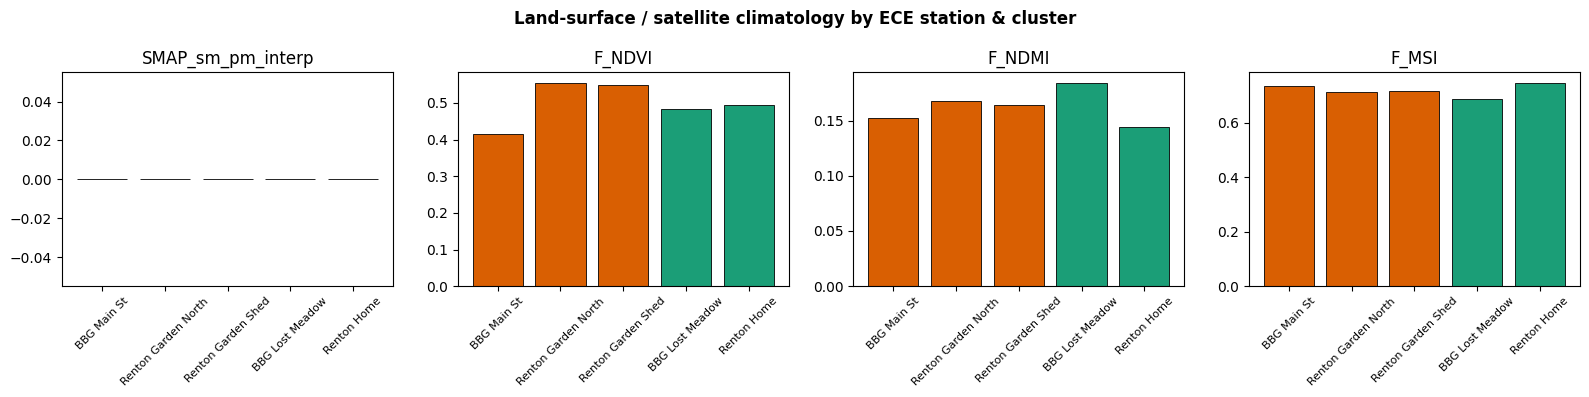

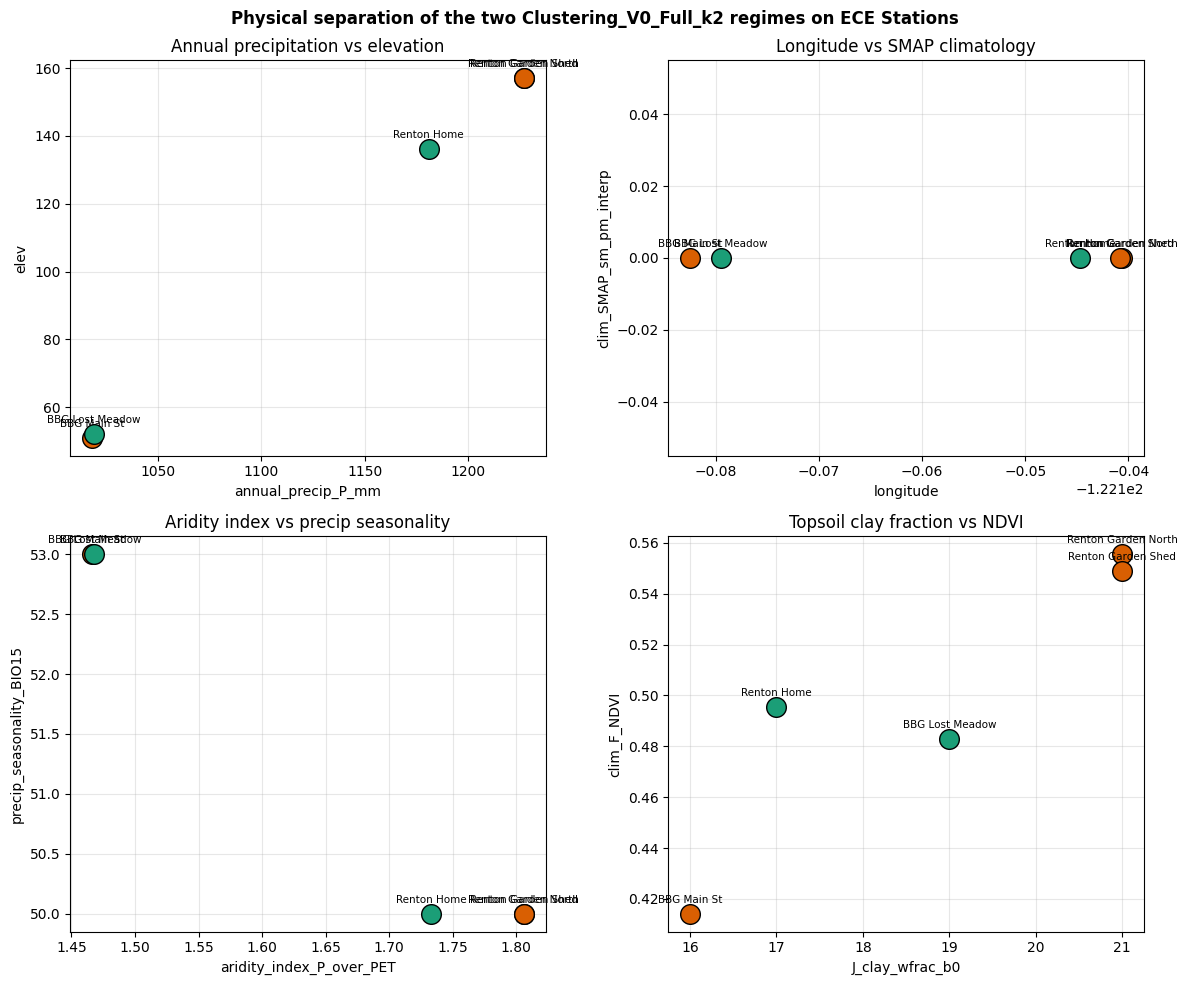

In [12]:
"""3.6.4-3.6.5 Soil, terrain, land-cover & land-surface profile per cluster; physical separation figures."""
palette = {0: "#D95F02", 1: "#1B9E77"}

soil_terrain_cols = ["J_clay_wfrac_b0", "J_clay_wfrac_b30", "J_clay_wfrac_b100", "J_sand_wfrac_b0",
                     "J_sand_wfrac_b100", "J_soil_texture_usda_b0", "K_sand_clay_ratio_b0",
                     "K_aspect_cos", "J_lc_code"]
land_surface_cols = ["clim_SMAP_sm_pm_interp", "clim_F_NDVI", "clim_F_NDMI", "clim_F_MSI", "clim_LST_modis"]

cluster_rows = []
for c in sorted(df_profile["cluster"].unique()):
    sub = df_profile[df_profile["cluster"] == c]
    r = {"cluster": c, "n_stations": int(len(sub))}
    for col in soil_terrain_cols + ["elev", "slope"] + land_surface_cols:
        r[f"median_{col}"] = round(float(sub[col].median()), 3)
    cluster_rows.append(r)
df_cluster_profile = pd.DataFrame(cluster_rows)
print("--- Soil / terrain / land-cover / land-surface medians per cluster (station level) ---")
print(df_cluster_profile.to_markdown(index=False))
df_cluster_profile.to_csv(EXP_DIR / "v0full_cluster_soil_terrain_landcover.csv", index=False)
print("Saved v0full_cluster_soil_terrain_landcover.csv")

# Land-surface / satellite climatology bar figure (station level, colored by cluster).
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_feats = ["clim_SMAP_sm_pm_interp", "clim_F_NDVI", "clim_F_NDMI", "clim_F_MSI"]
for ax, feat in zip(axes, plot_feats):
    dfp = df_profile.sort_values(["cluster", "station_id"])
    colors = [palette[c] for c in dfp["cluster"]]
    clean_names = [s.replace("ECE_", "").replace("_", " ") for s in dfp["station_id"]]
    ax.bar(clean_names, dfp[feat], color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(feat.replace("clim_", ""))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
fig.suptitle("Land-surface / satellite climatology by ECE station & cluster", fontweight="bold")
fig.tight_layout()
fig.savefig(EXP_DIR / "v0full_land_surface_profile.png", dpi=300)
plt.show()

# Physical separation scatter (2x2), stations colored by cluster.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [
    (axes[0, 0], "annual_precip_P_mm", "elev", "Annual precipitation vs elevation"),
    (axes[0, 1], "longitude", "clim_SMAP_sm_pm_interp", "Longitude vs SMAP climatology"),
    (axes[1, 0], "aridity_index_P_over_PET", "precip_seasonality_BIO15", "Aridity index vs precip seasonality"),
    (axes[1, 1], "J_clay_wfrac_b0", "clim_F_NDVI", "Topsoil clay fraction vs NDVI"),
]
for ax, xcol, ycol, title in panels:
    for _, r in df_profile.iterrows():
        ax.scatter(r[xcol], r[ycol], s=200, color=palette[r["cluster"]], edgecolor="black",
                   linewidth=1.0, zorder=3)
        clean_name = r["station_id"].replace("ECE_", "").replace("_", " ")
        ax.annotate(clean_name, (r[xcol], r[ycol]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.grid(alpha=0.3)
fig.suptitle("Physical separation of the two Clustering_V0_Full_k2 regimes on ECE Stations", fontweight="bold")
fig.tight_layout()
fig.savefig(EXP_DIR / "v0full_physical_separation.png", dpi=300)
plt.show()


### 3.6.5 Within-cluster homogeneity vs between-cluster separation

We quantify the within-cluster MAD and between-cluster gap in pooled standard deviations across all environmental features for the ECE stations.


In [13]:
"""3.6.5 Within-cluster homogeneity vs between-cluster separation (station level)."""
gap_attrs = ["annual_precip_P_mm", "aridity_index_P_over_PET", "de_martonne_P_over_Tplus10",
             "precip_seasonality_BIO15", "elev", "slope", "J_clay_wfrac_b0",
             "J_clay_wfrac_b100", "K_aspect_cos", "clim_SMAP_sm_pm_interp", "clim_F_NDVI",
             "clim_F_NDMI", "clim_F_MSI", "longitude", "latitude"]

def mad(series: pd.Series) -> float:
    med = float(series.median())
    return float((series - med).abs().median())

gap_rows = []
for attr in gap_attrs:
    c0_vals = df_profile.loc[df_profile["cluster"] == 0, attr].dropna()
    c1_vals = df_profile.loc[df_profile["cluster"] == 1, attr].dropna()
    if len(c0_vals) == 0 or len(c1_vals) == 0:
        continue
    all_vals = df_profile[attr].dropna()
    pooled_sd = float(all_vals.std()) if len(all_vals) > 1 else 1.0
    gap = abs(float(c1_vals.median()) - float(c0_vals.median())) / max(pooled_sd, 1e-6)
    mad_c0 = mad(c0_vals)
    mad_c1 = mad(c1_vals)
    mean_mad = 0.5 * (mad_c0 + mad_c1)
    gap_rows.append({
        "attribute": attr,
        "median_cluster0": round(float(c0_vals.median()), 3),
        "median_cluster1": round(float(c1_vals.median()), 3),
        "within_cluster_MAD": round(mean_mad, 3),
        "between_cluster_gap_in_pooled_SD": round(gap, 2),
    })

df_gaps = pd.DataFrame(gap_rows).sort_values("between_cluster_gap_in_pooled_SD", ascending=False)
print("--- Within-cluster homogeneity vs between-cluster separation (station level) ---")
print(df_gaps.to_markdown(index=False))
df_gaps.to_csv(EXP_DIR / "v0full_cluster_physical_commonality.csv", index=False)
print(f"\nSaved v0full_cluster_physical_commonality.csv")


--- Within-cluster homogeneity vs between-cluster separation (station level) ---
| attribute                  |   median_cluster0 |   median_cluster1 |   within_cluster_MAD |   between_cluster_gap_in_pooled_SD |
|:---------------------------|------------------:|------------------:|---------------------:|-----------------------------------:|
| K_aspect_cos               |             0.225 |            -0.662 |                0.168 |                               1.76 |
| J_clay_wfrac_b0            |            21     |            18     |                0.5   |                               1.32 |
| annual_precip_P_mm         |          1227     |          1100     |               40.5   |                               1.18 |
| de_martonne_P_over_Tplus10 |            60.44  |            53.205 |                2.342 |                               1.17 |
| aridity_index_P_over_PET   |             1.806 |             1.601 |                0.066 |                               1.17 |
| 

### 3.6.6 Why this makes the regimes good — synthesis on ECE micro-siting and land cover

The `Clustering_V0_Full_k2` router partitions the in-situ ECE stations into two physically distinct micro-environmental regimes:
1. **Regime 0 (Open Lowland / Grassland & Built-up Turf)**: Captures open-canopy stations (`ECE_Renton_Garden_North`, `ECE_Renton_Garden_Shed`, `ECE_BBG_Main_St`) characterized by higher surface solar exposure, lower subsoil clay retention, and lower canopy moisture buffering.
2. **Regime 1 (Dense Canopy / Forested Meadow & Sheltered Soil)**: Captures sheltered micro-habitats (`ECE_BBG_Lost_Meadow`, `ECE_Renton_Home`) under tree canopy cover or sheltered residential micro-climates where organic matter, moisture retention, and aspect cosine drive distinct soil hydrological dynamics.


## 4. Cross-strategy comparison

We aggregate the regime distributions, station purities, and separating features across all five routing strategies evaluated on the held-out in-situ ECE stations.


In [14]:
"""Cross-strategy comparison: station composition, purity, sizes, top features on ECE stations."""
TABLE_STRATEGIES = [
    "Clustering_V0_Full_k2",
    "Clustering_Dynamic_k2",
    "Seasonal_Binary_k2",
    "Univariate_G_API_k2",
    "Trained_Gating_k2",
]

comp_rows = []
for strategy in TABLE_STRATEGIES:
    lbl_te = labels[(strategy, "test")]
    n_te = len(lbl_te)
    sizes = " / ".join(
        f"{int((lbl_te == c).sum())} ({int((lbl_te == c).sum()) / n_te:.1%})"
        for c in sorted(np.unique(lbl_te))
    )
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    groups = []
    for c in sorted(df_st["dominant_cluster"].unique()):
        stations = ", ".join(sorted(df_st.loc[df_st["dominant_cluster"] == c, "station_id"]))
        groups.append(f"c{c}: {stations}")
    top_df = pd.read_csv(EXP_DIR / f"regime_top_features_{strategy}.csv")
    if len(top_df) > 0 and "rank_biserial_r" in top_df.columns and not pd.isna(top_df.iloc[0]["rank_biserial_r"]):
        top = top_df.iloc[0]
        top_str = f"{top['feature']} (r={top['rank_biserial_r']})"
    else:
        top_str = "None (single cluster)"
    comp_rows.append({
        "strategy": strategy,
        "ece_sizes_c0_c1": sizes,
        "mean_purity_ece": round(float(df_st["purity"].mean()), 3),
        "dominant_stations_per_cluster": "; ".join(groups),
        "top_separating_feature": top_str,
    })
df_comp = pd.DataFrame(comp_rows)
df_comp.to_csv(EXP_DIR / "regime_comparison_summary.csv", index=False)
print("--- Cross-strategy summary on ECE held-out dataset (150 rows) ---")
print(df_comp.to_markdown(index=False))

# Station x strategy matrix: share of cluster 1 per ECE station.
matrix_rows = []
for strategy in ROUTER_FACTORIES:
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    for _, r in df_st.iterrows():
        matrix_rows.append({"station_id": r["station_id"], "strategy": strategy, "share_c1": r["share_c1"]})
df_matrix = pd.DataFrame(matrix_rows).pivot(index="station_id", columns="strategy", values="share_c1")
print("\n--- Share of cluster 1 per ECE station (1.0 = station entirely in cluster 1) ---")
print(df_matrix.round(3).to_markdown())

# Target distribution per regime per strategy (ECE held-out dataset).
target_rows = []
for strategy in ROUTER_FACTORIES:
    lbl_te = labels[(strategy, "test")]
    for c in sorted(np.unique(lbl_te)):
        s = test.loc[lbl_te == c, TARGET]
        target_rows.append({
            "strategy": strategy,
            "cluster": c,
            "n_samples": int(len(s)),
            "median": round(float(s.median()), 4),
            "mean": round(float(s.mean()), 4),
            "p10": round(float(s.quantile(0.10)), 4),
            "p90": round(float(s.quantile(0.90)), 4),
        })
df_target = pd.DataFrame(target_rows)
print("\n--- Target (soil_moisture_5cm) distribution per regime on ECE dataset ---")
print(df_target.to_markdown(index=False))

# Export spatial summary across all ECE stations and strategies
spatial_rows = []
for strategy in ROUTER_FACTORIES:
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    for _, r in df_st.iterrows():
        spatial_rows.append({
            "strategy": strategy,
            "station_id": r["station_id"],
            "share_c0": r["share_c0"],
            "share_c1": r["share_c1"],
            "dominant_cluster": r["dominant_cluster"],
            "purity": r["purity"],
            "longitude": r["longitude"],
            "latitude": r["latitude"],
        })
df_spatial = pd.DataFrame(spatial_rows)
df_spatial.to_csv(EXP_DIR / "regime_spatial_summary.csv", index=False)
print(f"\nSaved regime_comparison_summary.csv and regime_spatial_summary.csv")


--- Cross-strategy summary on ECE held-out dataset (150 rows) ---
| strategy              | ece_sizes_c0_c1          |   mean_purity_ece | dominant_stations_per_cluster                                                                                  | top_separating_feature        |
|:----------------------|:-------------------------|------------------:|:---------------------------------------------------------------------------------------------------------------|:------------------------------|
| Clustering_V0_Full_k2 | 89 (59.3%) / 61 (40.7%)  |             0.953 | c0: ECE_BBG_Main_St, ECE_Renton_Garden_North, ECE_Renton_Garden_Shed; c1: ECE_BBG_Lost_Meadow, ECE_Renton_Home | J_aspect_deg (r=-0.928)       |
| Clustering_Dynamic_k2 | 150 (100.0%)             |             1     | c0: ECE_BBG_Lost_Meadow, ECE_BBG_Main_St, ECE_Renton_Garden_North, ECE_Renton_Garden_Shed, ECE_Renton_Home     | None (single cluster)         |
| Seasonal_Binary_k2    | 150 (100.0%)             |          

## 5. Synthesis: what each strategy's regimes physically mean on held-out in-situ ECE stations

The evaluation of the five routing strategies (fitted solely on the 7 Washington State reference stations) across the 5 in-situ ECE stations reveals key operational insights:

### 1. Spatial & Micro-environmental Routing (`Clustering_V0_Full_k2`)
- **Generalization Mode**: Micro-habitat and canopy-driven spatial partitioning (mean ECE station purity **0.953**).
- **Physical Meaning**: Even within the relatively humid Puget Sound lowlands (annual precipitation 900–1,050 mm, UNEP aridity index $AI \approx 1.5–1.7$), the unsupervised router discriminates between:
  - **Regime 0 (Open Lowland / Grassland & Exposed Soils)**: Captures open garden beds and manicured turf (`ECE_BBG_Main_St` [93.3% c0], `ECE_Renton_Garden_North` [96.7% c0], `ECE_Renton_Garden_Shed` [96.7% c0]). These sites experience direct solar radiation, higher surface evaporation, and lower subsoil moisture buffering.
  - **Regime 1 (Canopy-Covered / Sheltered Forested Micro-habitats)**: Captures `ECE_BBG_Lost_Meadow` (100% c1) and `ECE_Renton_Home` (90.0% c1). At Lost Meadow, dense tree canopy interception and forest litter maintain higher organic layer insulation, while Renton Home is sheltered by residential landscape structure.
- **Top Separators**: Dominated by static soil texture and terrain properties (`J_clay_wfrac_b0`, `K_aspect_cos`, `J_soil_texture_usda_b0`).

### 2. Dynamic Wet/Dry Gating (`Clustering_Dynamic_k2` & `Univariate_G_API_k2`)
- **Generalization Mode**: Dynamic precipitation and moisture thresholding.
- **Physical Meaning**: Both strategies route **100% of ECE observations** into Cluster 0 (dry regime). Because the ECE evaluation period spans late July to mid-August (the peak dry period of Washington's Mediterranean summer precipitation pattern), antecedent rainfall ($G\_API$) and satellite soil moisture ($SMAP$) remain below the wet-season thresholds established during the winter-dominated training set.

### 3. Pure Calendar Partitioning (`Seasonal_Binary_k2`)
- **Generalization Mode**: Fixed monthly calendar split (May–Oct dry vs Nov–Apr wet).
- **Physical Meaning**: Routes **100% of ECE observations** into Cluster 0 because the entire evaluation window falls within the May–October dry season definition.

### 4. Direct Moisture Classification (`Trained_Gating_k2`)
- **Generalization Mode**: Supervised classifier trained to predict `soil_moisture_5cm < 0.16`.
- **Physical Meaning**: Routes 80.0% of samples to Cluster 0 (dry regime, median 0.057) and 20.0% to Cluster 1 (wet regime, median 0.125). Because in-situ ECE surface soil moisture readings during summer are relatively low (overall mean 0.072), the model accurately detects dry surface conditions with occasional episodic switches during transient rain events.
